In [ ]:
from google.colab import drive
drive.mount("/content/drive")


In [ ]:
from pathlib import Path
import os
import sys

PROJECT_DIR = Path(
    "/content/drive/MyDrive/kalshi-market-engine-v29-split-relaxed-paper"
)

CHECKPOINT = Path(
    "/content/drive/MyDrive/"
    "kalshi_polymarket_ditto_v3_final/"
    "deberta_v3_checkpoints/"
    "checkpoint-588"
)

os.chdir(PROJECT_DIR)

print("Project exists:   ", PROJECT_DIR.exists())
print("Checkpoint exists:", CHECKPOINT.exists())


In [ ]:
!pip install -q -r requirements.txt


In [ ]:
os.environ["EQUIV_MODEL_PATH"] = str(CHECKPOINT)

os.environ["EQUIV_THRESHOLD"] = "0.0029228702187538147"
os.environ["EQUIV_DEVICE"] = "cuda"
os.environ["EQUIV_BATCH_SIZE"] = "64"

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("Model:", os.environ["EQUIV_MODEL_PATH"])
print("Threshold:", os.environ["EQUIV_THRESHOLD"])


In [ ]:
from src.arbitrage.equivalence_matcher import EquivalenceMatcher

matcher = EquivalenceMatcher.from_env()

print("✅ Matcher loaded")
print("Device:", matcher.device)
print("Threshold:", matcher.threshold)


In [ ]:
!pytest -q tests/test_v29_split_relaxed.py tests/test_universal_matcher_offline.py


# Matching and Semantic Filtering


In [ ]:
import json, os, sys, torch
from datetime import datetime, timezone
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/kalshi-market-engine-v29-split-relaxed-paper")
CHECKPOINT = Path(
    "/content/drive/MyDrive/kalshi_polymarket_ditto_v3_final/"
    "deberta_v3_checkpoints/checkpoint-588"
)
STORE = Path("/content/drive/MyDrive/kalshi-arbitrage-matcher-results")

assert torch.cuda.is_available(), "GPU runtime is not enabled."
gpu_name = torch.cuda.get_device_name(0)
print("GPU:", gpu_name)

assert PROJECT_DIR.exists(), PROJECT_DIR
assert CHECKPOINT.exists(), CHECKPOINT

needed_filters = [
    "production_veto_v3.py",
    "production_veto_v4.py",
    "production_veto_v5.py",
    "production_veto_v6.py",
    "production_veto_v7.py",
    "production_veto_v8_precision.py",
    "production_veto_v8_1_precision.py",
]
for name in needed_filters:
    assert (PROJECT_DIR / name).exists(), f"Missing: {name}"

run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
RUN_DIR = STORE / "final_runs" / run_id
RUN_DIR.mkdir(parents=True, exist_ok=False)

os.environ["FINAL_RUN_DIR"] = str(RUN_DIR)

manifest = {
    "run_id": run_id,
    "started_utc": datetime.now(timezone.utc).isoformat(),
    "gpu": gpu_name,
    "paper_only": True,
    "checkpoint": str(CHECKPOINT),
    "equiv_threshold": float(os.environ["EQUIV_THRESHOLD"]),
    "equiv_batch_size": int(os.environ["EQUIV_BATCH_SIZE"]),
    "semantic_filters": ["DeBERTa/engine", "V7", "V8", "V8.1"],
}
(RUN_DIR / "00_run_manifest.json").write_text(json.dumps(manifest, indent=2))
(STORE / "CURRENT_FINAL_RUN.txt").write_text(str(RUN_DIR))

print("Final run folder:")
print(RUN_DIR)
print("\nAll matching outputs will be saved here before the GPU is released.")


In [ ]:
!bash -lc 'set -o pipefail; python -m src.arbitrage.paper_engine_v29 discover \
    --confirm-top 50 \
    --confirmations 2 \
    --confirm-delay 0.25 \
    --no-figures \
    2>&1 | tee "$FINAL_RUN_DIR/01_discovery.log"'


In [ ]:
import ast, json, os, shutil, importlib.util
from datetime import datetime, timezone
from pathlib import Path
import pandas as pd

PROJECT = Path("/content/drive/MyDrive/kalshi-market-engine-v29-split-relaxed-paper")
PROCESSED = PROJECT / "data" / "processed"
STORE = Path("/content/drive/MyDrive/kalshi-arbitrage-matcher-results")
RUN_DIR = Path(os.environ["FINAL_RUN_DIR"])

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, str(path))
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

def parse_dict(x):
    if isinstance(x, dict):
        return x
    if x is None:
        return {}
    try:
        if pd.isna(x):
            return {}
    except Exception:
        pass
    s = str(x)
    for loader in (json.loads, ast.literal_eval):
        try:
            obj = loader(s)
            return obj if isinstance(obj, dict) else {}
        except Exception:
            pass
    return {}

def clean(x):
    return "" if pd.isna(x) else str(x).strip()

def find_sig_col(df, side):
    options = (
        ["ksig", "kalshi_signature", "kalshi_sig", "signature_kalshi"]
        if side == "k"
        else ["psig", "polymarket_signature", "poly_signature",
              "polymarket_sig", "poly_sig", "signature_polymarket"]
    )
    for c in options:
        if c in df.columns:
            return c
    for c in df.columns:
        lc = c.lower()
        if side == "k" and "kalshi" in lc and "sig" in lc:
            return c
        if side == "p" and ("poly" in lc or "polymarket" in lc) and "sig" in lc:
            return c
    return None

def save(df, name):
    p = RUN_DIR / name
    df.to_csv(p, index=False)
    print(f"Saved {name}: {len(df):,}")
    return p

required = [
    "open_markets.parquet",
    "polymarket_coverage_latest.csv",
    "validated_cross_platform.csv",
    "equivalence_audit.csv",
    "equivalence_summary.csv",
]
for name in required:
    src = PROCESSED / name
    assert src.exists() and src.stat().st_size > 0, f"Missing: {src}"

for src in PROCESSED.iterdir():
    if src.is_file():
        shutil.copy2(src, RUN_DIR / f"01_engine_{src.name}")

print("Raw V29 outputs preserved.")

accepted = pd.read_csv(PROCESSED / "validated_cross_platform.csv")
audit = pd.read_csv(PROCESSED / "equivalence_audit.csv")

if "polymarket_question" not in accepted and "poly_question" in accepted:
    accepted["polymarket_question"] = accepted["poly_question"]
if "polymarket_question" not in audit and "poly_question" in audit:
    audit["polymarket_question"] = audit["poly_question"]

KCOL = find_sig_col(audit, "k")
PCOL = find_sig_col(audit, "p")
assert KCOL and PCOL, f"Signature columns not found: {KCOL}, {PCOL}"

keys = ["kalshi_ticker", "kalshi_title", "polymarket_question"]
for c in keys:
    assert c in accepted.columns and c in audit.columns, c

accepted["_key"] = list(zip(*(accepted[c].map(clean) for c in keys)))
audit["_key"] = list(zip(*(audit[c].map(clean) for c in keys)))
groups = {k: g for k, g in audit.groupby("_key", sort=False)}

def resolve(row):
    g = groups.get(row["_key"])
    if g is None:
        raise RuntimeError(f"No audit signature row for {row['_key']}")
    g = g.copy()

    verdict_col = next((c for c in ["verdict", "match_verdict", "decision"] if c in g), None)
    if verdict_col:
        eq = g[g[verdict_col].astype(str).str.upper().eq("EQUIVALENT")]
        if len(eq):
            g = eq

    ac = next((c for c in ["score", "equivalence_score", "equivalence_probability"] if c in g), None)
    rc = next((c for c in ["equivalence_score", "score", "equivalence_probability"] if c in row.index), None)
    if ac and rc and pd.notna(row[rc]):
        try:
            dif = (pd.to_numeric(g[ac], errors="coerce") - float(row[rc])).abs()
            close = g[dif <= 1.5e-6]
            g = close if len(close) else g[dif == dif.min()]
        except Exception:
            pass

    sigs = g[[KCOL, PCOL]].astype(str).drop_duplicates()
    if len(sigs) != 1:
        raise RuntimeError(f"Ambiguous signature resolution for {row['_key']}")
    return g.iloc[0]

ksigs, psigs = [], []
for i, row in accepted.iterrows():
    ar = resolve(row)
    ksigs.append(ar[KCOL])
    psigs.append(ar[PCOL])
    if (i + 1) % 1000 == 0:
        print(f"Signatures: {i+1:,}/{len(accepted):,}")

accepted["ksig_raw"] = ksigs
accepted["psig_raw"] = psigs
accepted = accepted.drop(columns=["_key"])
save(accepted, "02_deberta_engine_pass.csv")

v7 = load_module("v7_finalrun", PROJECT / "production_veto_v7.py")
v8 = load_module("v8_finalrun", PROJECT / "production_veto_v8_precision.py")
v81 = load_module("v81_finalrun", PROJECT / "production_veto_v8_1_precision.py")

master = accepted.reset_index(drop=True).copy()

v7_pass, v7_reason = [], []

for i, row in master.iterrows():
    reason = v7.veto(
        row.to_dict(),
        parse_dict(row["ksig_raw"]),
        parse_dict(row["psig_raw"]),
    )
    ok = reason is None
    v7_pass.append(ok)
    v7_reason.append("PASS" if ok else str(reason))
    if (i + 1) % 1000 == 0:
        print(f"V7: {i+1:,}/{len(master):,}")

master["v7_pass"] = v7_pass
master["v7_reason"] = v7_reason

save(master, "03_v7_audit.csv")
save(master[master["v7_pass"]], "03_v7_pass.csv")
save(master[~master["v7_pass"]], "03_v7_reject.csv")

master["v8_decision"] = "NOT_REACHED"
master["v8_reason"] = "V7_REJECT"

v7_idx = master.index[master["v7_pass"]]

for n, idx in enumerate(v7_idx, 1):
    row = master.loc[idx]
    cert = parse_dict(row["equivalence_certificate"]) if "equivalence_certificate" in master.columns else {}
    r = v8.pair_decision(
        row.to_dict(),
        parse_dict(row["ksig_raw"]),
        parse_dict(row["psig_raw"]),
        cert,
    )
    master.at[idx, "v8_decision"] = r["decision"]
    master.at[idx, "v8_reason"] = r["reason"]
    if n % 1000 == 0:
        print(f"V8: {n:,}/{len(v7_idx):,}")

save(master[master["v7_pass"]], "04_v8_audit.csv")
save(master[master["v8_decision"] == "PASS"], "04_v8_pass.csv")
save(master[master["v8_decision"] == "REVIEW"], "04_v8_review.csv")
save(master[master["v8_decision"] == "REJECT"], "04_v8_reject.csv")

master["v8_1_decision"] = "NOT_REACHED"
master["v8_1_reason"] = "V8_NOT_PASS"

v8_idx = master.index[master["v8_decision"] == "PASS"]

for n, idx in enumerate(v8_idx, 1):
    row = master.loc[idx]
    cert = parse_dict(row["equivalence_certificate"]) if "equivalence_certificate" in master.columns else {}
    r = v81.pair_decision(
        row.to_dict(),
        parse_dict(row["ksig_raw"]),
        parse_dict(row["psig_raw"]),
        cert,
    )
    master.at[idx, "v8_1_decision"] = r["decision"]
    master.at[idx, "v8_1_reason"] = r["reason"]
    if n % 250 == 0:
        print(f"V8.1: {n:,}/{len(v8_idx):,}")

final_pass = master[master["v8_1_decision"] == "PASS"].copy()
final_review = master[master["v8_1_decision"] == "REVIEW"].copy()
final_reject = master[master["v8_1_decision"] == "REJECT"].copy()

save(master[master["v8_decision"] == "PASS"], "05_v8_1_audit.csv")
save(final_pass, "05_v8_1_pass.csv")
save(final_review, "05_v8_1_review.csv")
save(final_reject, "05_v8_1_reject.csv")

def status(r):
    if not r["v7_pass"]:
        return "REJECTED_V7"
    if r["v8_decision"] == "REJECT":
        return "REJECTED_V8"
    if r["v8_decision"] == "REVIEW":
        return "REVIEW_V8"
    if r["v8_1_decision"] == "REVIEW":
        return "REVIEW_V8_1"
    if r["v8_1_decision"] == "REJECT":
        return "REJECTED_V8_1"
    if r["v8_1_decision"] == "PASS":
        return "SEMANTIC_PASS"
    return "NOT_REACHED"

master["final_status"] = master.apply(status, axis=1)
save(master, "06_master_candidate_audit.csv")

funnel = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "engine_accepted": int(len(master)),
    "equivalence_audit_rows_retained": int(len(audit)),
    "v7_pass": int(master["v7_pass"].sum()),
    "v7_reject": int((~master["v7_pass"]).sum()),
    "v8_pass": int((master["v8_decision"] == "PASS").sum()),
    "v8_review": int((master["v8_decision"] == "REVIEW").sum()),
    "v8_reject": int((master["v8_decision"] == "REJECT").sum()),
    "v8_1_pass": int((master["v8_1_decision"] == "PASS").sum()),
    "v8_1_review": int((master["v8_1_decision"] == "REVIEW").sum()),
    "v8_1_reject": int((master["v8_1_decision"] == "REJECT").sum()),
}

(RUN_DIR / "matcher_funnel.json").write_text(json.dumps(funnel, indent=2))

manifest_path = RUN_DIR / "00_run_manifest.json"
manifest = json.loads(manifest_path.read_text())
manifest["matching_completed_utc"] = datetime.now(timezone.utc).isoformat()
manifest["matching_counts"] = funnel
manifest["cpu_handoff_watchlist"] = str(RUN_DIR / "05_v8_1_pass.csv")
manifest_path.write_text(json.dumps(manifest, indent=2))

(STORE / "CURRENT_FINAL_RUN.txt").write_text(str(RUN_DIR))

print("\n" + "=" * 72)
print("A100 MATCHING HALF COMPLETE")
print("=" * 72)
print("Engine accepted :", f"{len(master):,}")
print("V7 pass         :", f"{funnel['v7_pass']:,}")
print("V8 pass         :", f"{funnel['v8_pass']:,}")
print("V8.1 pass       :", f"{funnel['v8_1_pass']:,}")
print("\nCPU handoff:", RUN_DIR / "05_v8_1_pass.csv")
print("Run folder :", RUN_DIR)


In [ ]:
import os, time
from pathlib import Path

RUN_DIR = Path(os.environ["FINAL_RUN_DIR"])

required = [
    "00_run_manifest.json",
    "01_discovery.log",
    "01_engine_validated_cross_platform.csv",
    "01_engine_equivalence_audit.csv",
    "01_engine_equivalence_summary.csv",
    "02_deberta_engine_pass.csv",
    "03_v7_audit.csv",
    "03_v7_pass.csv",
    "03_v7_reject.csv",
    "04_v8_audit.csv",
    "04_v8_pass.csv",
    "04_v8_review.csv",
    "04_v8_reject.csv",
    "05_v8_1_audit.csv",
    "05_v8_1_pass.csv",
    "05_v8_1_review.csv",
    "06_master_candidate_audit.csv",
    "matcher_funnel.json",
]

missing = [
    name for name in required
    if not (RUN_DIR / name).exists()
    or (RUN_DIR / name).stat().st_size == 0
]

assert not missing, f"DO NOT disconnect. Missing/empty files: {missing}"

print("All required A100-stage files verified.")
print("CPU handoff watchlist:")
print(RUN_DIR / "05_v8_1_pass.csv")
print("\nRun folder:")
print(RUN_DIR)

os.sync()
time.sleep(8)

from google.colab import runtime
runtime.unassign()


# Live Paper Monitoring


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import json
import os
from pathlib import Path

STORE = Path(
    "/content/drive/MyDrive/kalshi-arbitrage-matcher-results"
)

PROJECT = Path(
    "/content/drive/MyDrive/kalshi-market-engine-v29-split-relaxed-paper"
)

os.chdir(PROJECT)

RUN_DIR = Path(
    STORE.joinpath("CURRENT_FINAL_RUN.txt").read_text().strip()
)

WATCHLIST = RUN_DIR / "05_v8_1_pass.csv"
MANIFEST = RUN_DIR / "00_run_manifest.json"
FUNNEL = RUN_DIR / "matcher_funnel.json"

assert RUN_DIR.exists(), RUN_DIR
assert WATCHLIST.exists(), WATCHLIST
assert MANIFEST.exists(), MANIFEST
assert FUNNEL.exists(), FUNNEL

print("Final run folder:")
print(RUN_DIR)

print("\nCPU watchlist:")
print(WATCHLIST)

print("\nMatching funnel:")
print(json.loads(FUNNEL.read_text()))

%cd /content/drive/MyDrive/kalshi-market-engine-v29-split-relaxed-paper


In [ ]:
import inspect
import pandas as pd
from pathlib import Path

from src.arbitrage.paper_engine_v2 import (
    EngineConfig,
    _fetch_poly_books_snapshot,
    _fetch_kalshi_books_snapshot,
    _fetch_series_snapshot,
    _poly_levels_from_book,
    _taker_candidate,
    _series_ticker,
)

from src.api.polymarket_client import (
    get_market_by_id,
    parse_token_ids,
)

WATCHLIST = RUN_DIR / "05_v8_1_pass.csv"

watch = pd.read_csv(WATCHLIST)

print("=" * 80)
print("CPU PREFLIGHT")
print("=" * 80)

print("\nWatchlist rows:", len(watch))
print("Unique Kalshi:", watch["kalshi_ticker"].nunique())

if "poly_id" in watch.columns:
    print("Unique Polymarket:", watch["poly_id"].nunique())

print("\nWATCHLIST COLUMNS")
print("-" * 80)

for i, c in enumerate(watch.columns):
    print(i, c)

print("\n" + "=" * 80)
print("_taker_candidate SOURCE")
print("=" * 80)

print(inspect.getsource(_taker_candidate))

print("\n" + "=" * 80)
print("_poly_levels_from_book SOURCE")
print("=" * 80)

print(inspect.getsource(_poly_levels_from_book))

print("\n" + "=" * 80)
print("EXAMPLE WATCHLIST ROW")
print("=" * 80)

example_cols = [
    c for c in [
        "kalshi_ticker",
        "kalshi_title",
        "poly_id",
        "poly_question",
        "polymarket_question",
        "equivalence_score",
        "equivalence_certificate",
        "ksig_raw",
        "psig_raw",
        "v7_reason",
        "v8_reason",
        "v8_1_reason",
    ]
    if c in watch.columns
]

print(
    watch[example_cols]
    .head(1)
    .T
    .to_string()
)


In [ ]:
import ast
import json
import time
from math import floor
from datetime import datetime, timezone
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd

from src.api.polymarket_client import (
    get_market_by_id,
    parse_token_ids,
)

import src.arbitrage.paper_engine_v2 as pe

WATCHLIST = RUN_DIR / "05_v8_1_pass.csv"

QUOTE_OUT = RUN_DIR / "quote_history.csv"
OPP_OUT = RUN_DIR / "opportunity_history.csv"
BOOK_OUT = RUN_DIR / "orderbook_snapshots.jsonl"

watch = pd.read_csv(WATCHLIST)

print("=" * 80)
print("FINAL CPU LIVE SNAPSHOT")
print("=" * 80)
print("Semantic pairs:", len(watch))

config = pe.EngineConfig(
    bankroll=1000.0,
    max_bankroll_fraction=0.25,
    max_contracts=500,

    # We log everything ourselves, so these do NOT determine
    # whether an observation gets written.
    min_net_per_contract=0.0,
    min_return_on_capital=0.0,

    max_quote_skew_seconds=30.0,
    allow_taker_taker=True,
)

MIN_NET_PER_CONTRACT = 0.0025
MIN_ROC = 0.001
MIN_RAW_ROC = 0.0025
MIN_APR = 0.0075

def parse_dict(value):
    if isinstance(value, dict):
        return value

    if value is None:
        return {}

    try:
        if pd.isna(value):
            return {}
    except Exception:
        pass

    try:
        obj = ast.literal_eval(str(value))
        return obj if isinstance(obj, dict) else {}
    except Exception:
        return {}

def append_csv(path, rows):

    if not rows:
        return

    df = pd.DataFrame(rows)

    df.to_csv(
        path,
        mode="a",
        header=not path.exists(),
        index=False,
    )

def append_jsonl(path, obj):

    with open(path, "a", encoding="utf-8") as f:
        f.write(
            json.dumps(
                obj,
                default=str,
            )
            + "\n"
        )

def fetch_pm(poly_id):

    try:
        pm = get_market_by_id(
            str(poly_id)
        )

        return str(poly_id), pm, None

    except Exception as exc:

        return (
            str(poly_id),
            None,
            f"{type(exc).__name__}: {exc}",
        )

poly_market_map = {}
poly_failures = {}

poly_ids = (
    watch["poly_id"]
    .astype(str)
    .unique()
    .tolist()
)

print("\nHydrating Polymarket markets:", len(poly_ids))

with ThreadPoolExecutor(max_workers=8) as pool:

    futures = {
        pool.submit(fetch_pm, pid): pid
        for pid in poly_ids
    }

    for i, future in enumerate(
        as_completed(futures),
        1,
    ):

        pid, pm, error = future.result()

        if pm is not None:
            poly_market_map[pid] = pm
        else:
            poly_failures[pid] = error

        if i % 100 == 0 or i == len(poly_ids):

            print(
                f"Hydrated {i:,}/{len(poly_ids):,} | "
                f"success={len(poly_market_map):,} | "
                f"fail={len(poly_failures):,}"
            )

priceable = []
token_fail = 0

for _, r in watch.iterrows():

    pid = str(r["poly_id"])

    pm = poly_market_map.get(pid)

    if pm is None:
        continue

    try:
        tokens = parse_token_ids(pm)
    except Exception:
        token_fail += 1
        continue

    if not tokens or len(tokens) < 2:
        token_fail += 1
        continue

    priceable.append({
        "row": r,
        "ticker": str(r["kalshi_ticker"]),
        "poly_id": pid,
        "pm": pm,
        "tokens": (
            str(tokens[0]),
            str(tokens[1]),
        ),
    })

print("\nPriceable pairs:", len(priceable))
print("Token failures:", token_fail)

tickers = sorted({
    x["ticker"]
    for x in priceable
})

tokens = sorted({
    token
    for x in priceable
    for token in x["tokens"]
})

series = sorted({
    pe._series_ticker(x["ticker"])
    for x in priceable
})

print("\nKalshi books:", len(tickers))
print("Polymarket token books:", len(tokens))
print("Kalshi series:", len(series))

poly_books, poly_ts, poly_failures_books = (
    pe._fetch_poly_books_snapshot(
        tokens,
        chunk_size=100,
    )
)

kalshi_books, kalshi_ts, kalshi_failures = (
    pe._fetch_kalshi_books_snapshot(
        tickers,
        workers=12,
    )
)

series_cache, series_failures = (
    pe._fetch_series_snapshot(
        series,
        workers=8,
    )
)

print("\nBOOK SNAPSHOT COMPLETE")
print("Kalshi:", len(kalshi_books))
print("Polymarket:", len(poly_books))
print("Series:", len(series_cache))

def price_direction(
    row,
    pm,
    ticker,
    kbook,
    poly_levels,
    kalshi_side,
    sinfo,
    quote_skew,
):

    yes_levels = pe._kalshi_levels(
        kbook,
        "yes",
    )

    no_levels = pe._kalshi_levels(
        kbook,
        "no",
    )

    if kalshi_side == "yes":

        k_ask_levels = sorted(
            (
                {
                    "price": round(
                        1.0 - x["price"],
                        4,
                    ),
                    "size": x["size"],
                }
                for x in no_levels
            ),
            key=lambda x: x["price"],
        )

        p_levels = poly_levels["no"]

        strategy = (
            "K YES taker + P NO taker"
        )

    else:

        k_ask_levels = sorted(
            (
                {
                    "price": round(
                        1.0 - x["price"],
                        4,
                    ),
                    "size": x["size"],
                }
                for x in yes_levels
            ),
            key=lambda x: x["price"],
        )

        p_levels = poly_levels["yes"]

        strategy = (
            "K NO taker + P YES taker"
        )

    if not k_ask_levels or not p_levels:

        return None

    max_capital = (
        config.bankroll
        * config.max_bankroll_fraction
    )

    first_cost = (
        k_ask_levels[0]["price"]
        + p_levels[0]["price"]
    )

    max_qty = min(
        config.max_contracts,
        pe.floor_contracts(
            max_capital
            / max(first_cost, 1e-9)
        ),
    )

    if max_qty < 1:
        return None

    qty_choices = sorted(
        set([
            1,
            2,
            5,
            10,
            20,
            25,
            50,
            100,
            max_qty,
        ])
    )

    best = None

    for qty in qty_choices:

        if qty < 1 or qty > max_qty:
            continue

        kdepth = pe.consume_asks(
            k_ask_levels,
            qty,
        )

        pdepth = pe.consume_asks(
            p_levels,
            qty,
        )

        if (
            not kdepth.fully_filled
            or not pdepth.fully_filled
        ):
            continue

        kfee = pe.kalshi_fee(
            price=kdepth.average_price,
            contracts=qty,
            fee_type=sinfo.get("fee_type"),
            fee_multiplier=(
                sinfo.get("fee_multiplier")
                or 0
            ),
            maker=False,
        )

        if kfee is None:
            continue

        pfee = pe.polymarket_taker_fee(
            pdepth.average_price,
            qty,
            pm,
        )

        raw_cost = (
            kdepth.cost
            + pdepth.cost
        )

        gross = (
            qty
            - raw_cost
        )

        kalshi_fee = (
            kfee["cash_fee_upper"]
        )

        total_fees = (
            kalshi_fee
            + pfee
        )

        net = (
            gross
            - total_fees
        )

        capital = (
            raw_cost
            + total_fees
        )

        npc = net / qty

        roc = (
            net / capital
            if capital > 0
            else 0.0
        )

        result = {

            "timestamp_utc":
                datetime.now(
                    timezone.utc
                ).isoformat(),

            "kalshi_ticker":
                ticker,

            "poly_id":
                str(row["poly_id"]),

            "kalshi_title":
                row["kalshi_title"],

            "poly_question":
                row["poly_question"],

            "strategy":
                strategy,

            "quantity":
                qty,

            "kalshi_price":
                float(kdepth.average_price),

            "poly_price":
                float(pdepth.average_price),

            "poly_worst_price":
                float(pdepth.worst_price),

            "combined_raw_price":
                float(
                    raw_cost / qty
                ),

            "gross_edge_per_contract":
                float(
                    gross / qty
                ),

            "kalshi_fee_total":
                float(kalshi_fee),

            "poly_fee_total":
                float(pfee),

            "total_fee_per_contract":
                float(
                    total_fees / qty
                ),

            "net_profit":
                float(net),

            "net_per_contract":
                float(npc),

            "return_on_capital":
                float(roc),

            "capital":
                float(capital),

            "quote_skew_seconds":
                float(quote_skew),

            "poly_volume24hr":
                row.get(
                    "poly_volume24hr"
                ),

            "poly_liquidity":
                row.get(
                    "poly_liquidity"
                ),

            "equivalence_score":
                row.get(
                    "equivalence_score"
                ),

            "v7_reason":
                row.get("v7_reason"),

            "v8_reason":
                row.get("v8_reason"),

            "v8_1_reason":
                row.get("v8_1_reason"),

            "resolution_lane":
                row.get(
                    "resolution_lane"
                ),

            "resolution_rule_status":
                row.get(
                    "resolution_rule_status"
                ),

            "basis_risk_reserve_per_contract":
                row.get(
                    "basis_risk_reserve_per_contract"
                ),

        }

        if (
            best is None
            or result["net_profit"]
            > best["net_profit"]
        ):
            best = result

    return best

quote_rows = []
opportunity_rows = []

stats = {
    "pairs_total": len(priceable),
    "pairs_priced": 0,
    "missing_kalshi_book": 0,
    "missing_poly_book": 0,
    "missing_series": 0,
    "quote_skew_too_high": 0,
}

for i, item in enumerate(
    priceable,
    1,
):

    r = item["row"]

    ticker = item["ticker"]

    pm = item["pm"]

    yes_token, no_token = (
        item["tokens"]
    )

    kbook = kalshi_books.get(
        ticker
    )

    yes_book = poly_books.get(
        yes_token
    )

    no_book = poly_books.get(
        no_token
    )

    if kbook is None:

        stats[
            "missing_kalshi_book"
        ] += 1

        continue

    if (
        yes_book is None
        or no_book is None
    ):

        stats[
            "missing_poly_book"
        ] += 1

        continue

    sinfo = series_cache.get(
        pe._series_ticker(ticker)
    )

    if sinfo is None:

        stats[
            "missing_series"
        ] += 1

        continue

    kts = kalshi_ts.get(ticker)

    yts = poly_ts.get(yes_token)

    nts = poly_ts.get(no_token)

    if None in (
        kts,
        yts,
        nts,
    ):

        quote_skew = 999.0

    else:

        quote_skew = max(
            abs(kts - yts),
            abs(kts - nts),
            abs(yts - nts),
        )

    # IMPORTANT:
    # Snapshot skew is retained as diagnostic data.
    # We do not discard the observation here.
    # Fresh confirmation later applies the strict skew test.

    if (
        quote_skew
        > config.max_quote_skew_seconds
    ):

        stats[
            "quote_skew_too_high"
        ] += 1

    poly_levels = {

        "yes":
            pe._poly_levels_from_book(
                yes_book
            ),

        "no":
            pe._poly_levels_from_book(
                no_book
            ),

    }

    # --------------------------------------------------------
    # Save raw order books
    # --------------------------------------------------------

    append_jsonl(
        BOOK_OUT,
        {
            "timestamp_utc":
                datetime.now(
                    timezone.utc
                ).isoformat(),

            "kalshi_ticker":
                ticker,

            "poly_id":
                item["poly_id"],

            "yes_token":
                yes_token,

            "no_token":
                no_token,

            "kalshi_book":
                kbook,

            "poly_yes_book":
                yes_book,

            "poly_no_book":
                no_book,

            "quote_skew_seconds":
                quote_skew,
        },
    )

    # --------------------------------------------------------
    # Both complementary hedge directions
    # --------------------------------------------------------

    for side in (
        "yes",
        "no",
    ):

        result = price_direction(
            r,
            pm,
            ticker,
            kbook,
            poly_levels,
            side,
            sinfo,
            quote_skew,
        )

        if result is None:
            continue

        quote_rows.append(
            result
        )

        if (
            result[
                "net_per_contract"
            ]
            >= MIN_NET_PER_CONTRACT

            and

            result[
                "return_on_capital"
            ]
            >= MIN_ROC
        ):

            opportunity_rows.append(
                result
            )

    stats["pairs_priced"] += 1

    if i % 100 == 0:

        print(
            f"Priced {i:,}/{len(priceable):,} | "
            f"observations={len(quote_rows):,} | "
            f"positive={len(opportunity_rows):,}"
        )

append_csv(
    QUOTE_OUT,
    quote_rows,
)

append_csv(
    OPP_OUT,
    opportunity_rows,
)

snapshot_summary = {

    "timestamp_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    **stats,

    "strategy_observations":
        len(quote_rows),

    "positive_executable_strategies":
        len(opportunity_rows),

    "minimum_net_per_contract":
        MIN_NET_PER_CONTRACT,

    "minimum_return_on_capital":
        MIN_ROC,

}

with open(
    RUN_DIR / "cpu_snapshot_summary.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        snapshot_summary,
        f,
        indent=2,
    )

print("\n" + "=" * 80)
print("CPU SNAPSHOT COMPLETE")
print("=" * 80)

for k, v in snapshot_summary.items():
    print(f"{k}: {v}")

if opportunity_rows:

    opp_df = pd.DataFrame(
        opportunity_rows
    )

    print("\nTOP CURRENT OPPORTUNITIES")
    print("-" * 80)

    print(
        opp_df[
            [
                "kalshi_ticker",
                "strategy",
                "quantity",
                "net_per_contract",
                "net_profit",
                "return_on_capital",
                "quote_skew_seconds",
            ]
        ]
        .sort_values(
            "net_profit",
            ascending=False,
        )
        .head(30)
        .to_string(
            index=False
        )
    )

print("\nSaved:")
print(QUOTE_OUT)
print(OPP_OUT)
print(BOOK_OUT)
print(
    RUN_DIR
    / "cpu_snapshot_summary.json"
)


In [ ]:
import pandas as pd

import src.arbitrage.paper_engine_v2 as pe
import src.arbitrage.paper_engine_v3_v28 as p3

from src.api.polymarket_client import get_market_by_id

OPP_FILE = RUN_DIR / "opportunity_history.csv"
CONF_OUT = RUN_DIR / "confirmations.csv"
CONF_PASS_OUT = RUN_DIR / "confirmed_price_positive.csv"

opp = pd.read_csv(OPP_FILE)

print("=" * 80)
print("FRESH CONFIRMATION")
print("=" * 80)
print("Candidates:", len(opp))

engine_config = pe.EngineConfig(
    bankroll=1000.0,
    max_bankroll_fraction=0.25,
    max_contracts=500,
    min_net_per_contract=0.0025,
    min_return_on_capital=0.001,
    max_quote_skew_seconds=3.0,
    allow_taker_taker=True,
)

confirmation_config = p3.ConfirmationConfig(
    samples=5,
    delay_seconds=0.75,
    max_candidates=len(opp),
    max_per_topic=len(opp),
    maker_unknown_fill_penalty=0.05,
)

def candidate_from_row(r):

    return {
        "ticker": str(r["kalshi_ticker"]),
        "kalshi_title": str(r["kalshi_title"]),
        "poly_question": str(r["poly_question"]),
        "strategy": str(r["strategy"]),
        "quantity": int(r["quantity"]),
        "capital": float(r["capital"]),
        "gross_profit": (
            float(r["gross_edge_per_contract"])
            * int(r["quantity"])
        ),
        "kalshi_fee": float(r["kalshi_fee_total"]),
        "poly_fee": float(r["poly_fee_total"]),
        "net_profit": float(r["net_profit"]),
        "net_per_contract": float(r["net_per_contract"]),
        "return_on_capital": float(r["return_on_capital"]),
        "kalshi_price": float(r["kalshi_price"]),
        "poly_avg_price": float(r["poly_price"]),
        "poly_worst_price": float(r["poly_worst_price"]),
        "quote_skew_seconds": float(r["quote_skew_seconds"]),
        "kalshi_title": str(r["kalshi_title"]),
        "poly_question": str(r["poly_question"]),
        "equivalence_score": r.get("equivalence_score"),
    }

results = []

for i, (_, row) in enumerate(opp.iterrows(), 1):

    candidate = candidate_from_row(row)

    print("\n" + "=" * 80)
    print(f"CONFIRMING {i}/{len(opp)}")
    print("=" * 80)

    print(candidate["ticker"])
    print(candidate["strategy"])
    print(
        "Snapshot net/ct:",
        f"${candidate['net_per_contract']:.6f}"
    )

    try:

        pm = get_market_by_id(
            str(row["poly_id"])
        )

        series = p3._series_ticker(
            candidate["ticker"]
        )

        series_info = pe.get_series_info(
            series
        )

        result = p3.confirm_candidate(
            candidate,
            pm,
            series_info,
            engine_config,
            confirmation_config,
        )

        result["poly_id"] = str(row["poly_id"])
        result["snapshot_net_per_contract"] = float(
            row["net_per_contract"]
        )
        result["snapshot_quote_skew_seconds"] = float(
            row["quote_skew_seconds"]
        )

        results.append(result)

        print(
            "Status:",
            result["confirmation_status"]
        )

        print(
            "Samples:",
            f"{result['confirmations_positive']}/"
            f"{result['confirmations_required']}"
        )

        print(
            "Reason:",
            result["confirmation_reason"]
        )

        if result.get("worst_net_per_contract") is not None:

            print(
                "Worst net/ct:",
                f"${result['worst_net_per_contract']:.6f}"
            )

            print(
                "Worst profit:",
                f"${result['worst_net_profit']:.4f}"
            )

            print(
                "Max fresh skew:",
                f"{result['max_fetch_skew_seconds']:.3f}s"
            )

    except Exception as exc:

        print(
            "ERROR:",
            type(exc).__name__,
            str(exc),
        )

        results.append({
            "ticker": candidate["ticker"],
            "poly_id": str(row["poly_id"]),
            "kalshi_title": candidate["kalshi_title"],
            "poly_question": candidate["poly_question"],
            "strategy": candidate["strategy"],
            "confirmation_status": "ERROR",
            "confirmation_reason": (
                f"{type(exc).__name__}: {exc}"
            ),
        })

result_df = pd.DataFrame(results)

result_df.to_csv(
    CONF_OUT,
    index=False,
)

confirmed = result_df[
    result_df["confirmation_status"] == "CONFIRMED"
].copy()

confirmed.to_csv(
    CONF_PASS_OUT,
    index=False,
)

print("\n" + "=" * 80)
print("FRESH CONFIRMATION SUMMARY")
print("=" * 80)

print("Candidates tested:", len(result_df))
print("CONFIRMED:", len(confirmed))

print(
    "Rejected/error:",
    len(result_df) - len(confirmed)
)

if len(confirmed):

    show_cols = [
        "ticker",
        "kalshi_title",
        "poly_question",
        "strategy",
        "confirmations_positive",
        "confirmations_required",
        "worst_net_per_contract",
        "worst_net_profit",
        "max_fetch_skew_seconds",
        "confirmation_reason",
    ]

    show_cols = [
        c for c in show_cols
        if c in confirmed.columns
    ]

    print("\nCONFIRMED CANDIDATES")
    print("-" * 80)

    print(
        confirmed[
            show_cols
        ]
        .sort_values(
            "worst_net_profit",
            ascending=False
        )
        .to_string(index=False)
    )

print("\nSaved:")
print(CONF_OUT)
print(CONF_PASS_OUT)


In [ ]:
import json
import time
import pandas as pd
from pathlib import Path
from datetime import datetime, timezone

from src.api.polymarket_client import get_market_by_id
from src.api.kalshi_client import get_market_details

CONFIRMED_FILE = RUN_DIR / "confirmed_price_positive.csv"

RAW_JSONL = RUN_DIR / "raw_settlement_markets.jsonl"
RULES_CSV = RUN_DIR / "raw_settlement_rules.csv"

confirmed = pd.read_csv(CONFIRMED_FILE)

print("=" * 80)
print("RAW SETTLEMENT-RULE HYDRATION")
print("=" * 80)
print("Confirmed candidates:", len(confirmed))

assert len(confirmed) == 46, (
    f"Expected 46 confirmed candidates, found {len(confirmed)}"
)

def json_safe(obj):
    try:
        return json.loads(
            json.dumps(
                obj,
                default=str
            )
        )
    except Exception:
        return str(obj)

def text_value(obj, keys):

    if not isinstance(obj, dict):
        return ""

    for key in keys:

        val = obj.get(key)

        if val is None:
            continue

        if isinstance(val, str):
            if val.strip():
                return val.strip()

        elif isinstance(val, (dict, list)):
            try:
                return json.dumps(
                    val,
                    ensure_ascii=False,
                    default=str
                )
            except Exception:
                pass

        else:
            return str(val)

    return ""

def flatten_market_payload(payload):

    if not isinstance(payload, dict):
        return {}

    # Some API clients wrap the actual market
    # inside {"market": {...}}
    market = payload.get("market")

    if isinstance(market, dict):
        return market

    return payload

rows = []
raw_records = []

for i, (_, r) in enumerate(
    confirmed.iterrows(),
    1
):

    ticker = str(r["ticker"])
    poly_id = str(r["poly_id"])

    print(
        f"\n{i:02d}/{len(confirmed)} "
        f"{ticker}"
    )

    kalshi_raw = None
    poly_raw = None

    kalshi_error = ""
    poly_error = ""

    # --------------------------------------------------------
    # Kalshi
    # --------------------------------------------------------

    try:

        kalshi_raw = get_market_details(
            ticker
        )

    except Exception as exc:

        kalshi_error = (
            f"{type(exc).__name__}: {exc}"
        )

        print(
            "  Kalshi error:",
            kalshi_error
        )

    # Small courtesy delay
    time.sleep(0.05)

    # --------------------------------------------------------
    # Polymarket
    # --------------------------------------------------------

    try:

        poly_raw = get_market_by_id(
            poly_id
        )

    except Exception as exc:

        poly_error = (
            f"{type(exc).__name__}: {exc}"
        )

        print(
            "  Polymarket error:",
            poly_error
        )

    k = flatten_market_payload(
        kalshi_raw
    )

    p = flatten_market_payload(
        poly_raw
    )

    # --------------------------------------------------------
    # Preserve FULL raw payloads
    # --------------------------------------------------------

    raw_record = {

        "timestamp_utc":
            datetime.now(
                timezone.utc
            ).isoformat(),

        "ticker":
            ticker,

        "poly_id":
            poly_id,

        "strategy":
            r["strategy"],

        "kalshi_raw":
            json_safe(kalshi_raw),

        "polymarket_raw":
            json_safe(poly_raw),

        "kalshi_error":
            kalshi_error,

        "polymarket_error":
            poly_error,
    }

    raw_records.append(
        raw_record
    )

    # --------------------------------------------------------
    # Extract likely settlement fields into convenient table
    # --------------------------------------------------------

    kalshi_rules = text_value(
        k,
        [
            "rules_primary",
            "rules_secondary",
            "rules",
            "settlement_rules",
            "resolution_rules",
            "description",
        ],
    )

    kalshi_rules_primary = text_value(
        k,
        [
            "rules_primary",
            "rules",
            "settlement_rules",
        ],
    )

    kalshi_rules_secondary = text_value(
        k,
        [
            "rules_secondary",
            "additional_rules",
        ],
    )

    poly_rules = text_value(
        p,
        [
            "description",
            "rules",
            "resolutionSource",
            "resolution_source",
            "resolutionRules",
            "resolution_rules",
        ],
    )

    # Directional implication required by the hedge
    strategy = str(
        r["strategy"]
    )

    if strategy.startswith(
        "K YES"
    ):

        required_implication = (
            "P_YES_IMPLIES_K_YES"
        )

    elif strategy.startswith(
        "K NO"
    ):

        required_implication = (
            "K_YES_IMPLIES_P_YES"
        )

    else:

        required_implication = (
            "UNKNOWN"
        )

    rows.append({

        "ticker":
            ticker,

        "poly_id":
            poly_id,

        "kalshi_title":
            r.get(
                "kalshi_title",
                ""
            ),

        "poly_question":
            r.get(
                "poly_question",
                ""
            ),

        "strategy":
            strategy,

        "required_implication":
            required_implication,

        "worst_net_per_contract":
            r.get(
                "worst_net_per_contract"
            ),

        "worst_net_profit":
            r.get(
                "worst_net_profit"
            ),

        "max_fetch_skew_seconds":
            r.get(
                "max_fetch_skew_seconds"
            ),

        "kalshi_rules_primary":
            kalshi_rules_primary,

        "kalshi_rules_secondary":
            kalshi_rules_secondary,

        "kalshi_rules_combined":
            kalshi_rules,

        "polymarket_rules":
            poly_rules,

        "kalshi_close_time":
            text_value(
                k,
                [
                    "close_time",
                    "close_ts",
                    "expiration_time",
                    "expected_expiration_time",
                ],
            ),

        "kalshi_settlement_time":
            text_value(
                k,
                [
                    "latest_expiration_time",
                    "settlement_time",
                    "settlement_ts",
                ],
            ),

        "polymarket_end_date":
            text_value(
                p,
                [
                    "endDate",
                    "end_date",
                    "endDateIso",
                ],
            ),

        "polymarket_resolution_source":
            text_value(
                p,
                [
                    "resolutionSource",
                    "resolution_source",
                ],
            ),

        "kalshi_fetch_ok":
            kalshi_raw is not None,

        "polymarket_fetch_ok":
            poly_raw is not None,

        "kalshi_error":
            kalshi_error,

        "polymarket_error":
            poly_error,
    })

with open(
    RAW_JSONL,
    "w",
    encoding="utf-8",
) as f:

    for record in raw_records:

        f.write(
            json.dumps(
                record,
                ensure_ascii=False,
                default=str,
            )
            + "\n"
        )

rules = pd.DataFrame(rows)

rules.to_csv(
    RULES_CSV,
    index=False
)

print("\n" + "=" * 80)
print("RAW RULE HYDRATION COMPLETE")
print("=" * 80)

print(
    "Candidates:",
    len(rules)
)

print(
    "Kalshi fetched:",
    int(
        rules[
            "kalshi_fetch_ok"
        ].sum()
    ),
)

print(
    "Polymarket fetched:",
    int(
        rules[
            "polymarket_fetch_ok"
        ].sum()
    ),
)

print(
    "Both fetched:",
    int(
        (
            rules[
                "kalshi_fetch_ok"
            ]
            &
            rules[
                "polymarket_fetch_ok"
            ]
        ).sum()
    ),
)

print("\nRequired implication:")
print(
    rules[
        "required_implication"
    ]
    .value_counts()
    .to_string()
)

print("\nRule text coverage:")

print(
    "Kalshi rule text:",
    int(
        rules[
            "kalshi_rules_combined"
        ]
        .astype(str)
        .str.len()
        .gt(10)
        .sum()
    ),
)

print(
    "Polymarket rule text:",
    int(
        rules[
            "polymarket_rules"
        ]
        .astype(str)
        .str.len()
        .gt(10)
        .sum()
    ),
)

print("\nSaved:")
print(RAW_JSONL)
print(RULES_CSV)

controls = rules[
    rules["ticker"].str.contains(
        "BATMAN|TIME|F1|NASCAR",
        case=False,
        na=False,
    )
]

if len(controls):

    print(
        "\n" + "=" * 80
    )
    print(
        "CONTROL RULE EXTRACTS"
    )
    print(
        "=" * 80
    )

    for _, x in controls.iterrows():

        print(
            "\n" + "-" * 80
        )

        print(
            x["ticker"]
        )

        print(
            "Strategy:",
            x["strategy"]
        )

        print(
            "Required:",
            x[
                "required_implication"
            ]
        )

        print(
            "\nKALSHI RULES:"
        )

        print(
            str(
                x[
                    "kalshi_rules_combined"
                ]
            )[:2500]
        )

        print(
            "\nPOLYMARKET RULES:"
        )

        print(
            str(
                x[
                    "polymarket_rules"
                ]
            )[:2500]
        )


In [ ]:
import pandas as pd
from pathlib import Path

RULES_FILE = RUN_DIR / "raw_settlement_rules.csv"
CONFIRMED_FILE = RUN_DIR / "confirmed_price_positive.csv"

AUDIT_OUT = RUN_DIR / "settlement_audit.csv"
APPROVED_OUT = RUN_DIR / "trade_approved_watchlist.csv"

rules = pd.read_csv(RULES_FILE)
confirmed = pd.read_csv(CONFIRMED_FILE)

assert len(rules) == 46
assert len(confirmed) == 46
assert rules["ticker"].is_unique

PASS = {

    # Calgary-Shaw:
    # P YES -> K YES is safe for Mike Derry.
    "KXCALGARYSHAWBY-26SEP14-MDER":
        "P YES requires Mike Derry to win the same by-election; this implies Kalshi YES.",

    # Eredivisie
    "KXEREDIVISIE-27-AJA":
        "P YES requires Ajax to be declared 2026-27 Eredivisie champion; this implies Kalshi YES.",

    # NHL — direction P YES -> K YES
    "KXNHLEAST-27-PHI":
        "P YES requires Philadelphia to win the same Eastern Conference Finals; this implies Kalshi YES.",

    # House elections
    "KXCAELECTION-2634-AGON":
        "Both markets resolve from the same CA-34 election winner; required K YES -> P YES implication supported.",

    "KXCA11PERSON-26-SWIE":
        "Both markets resolve from the same CA-11 election winner; required K YES -> P YES implication supported.",

    "KXCA11PERSON-26-CCHA":
        "P YES requires Connie Chan to win the same CA-11 seat; this implies Kalshi YES.",

    # Democratic VP — required direction P YES -> K YES
    "KXVPRESNOMD-28-LJAM":
        "P YES requires LeBron James to be formally nominated and accept; this implies Kalshi YES.",

    "KXVPRESNOMD-28-BSAN":
        "P YES requires Bernie Sanders to be formally nominated and accept; this implies Kalshi YES.",

    "KXVPRESNOMD-28-BOBA":
        "P YES requires Barack Obama to be formally nominated and accept; this implies Kalshi YES.",

    "KXVPRESNOMD-28-ZMAM":
        "P YES requires Zohran Mamdani to be formally nominated and accept; this implies Kalshi YES.",

    "KXVPRESNOMD-28-REMA":
        "P YES requires Rahm Emanuel to be formally nominated and accept; this implies Kalshi YES.",

    # NFL awards — required direction P YES -> K YES
    "KXNFLDROTY-27-MDEL":
        "P YES makes Mansoor Delane an official AP Defensive Rookie of the Year winner; this implies Kalshi YES.",

    "KXNFLCOTY-27-JMIN":
        "P YES makes Jesse Minter an official AP Coach of the Year winner; this implies Kalshi YES.",

    # Presidential nominations
    "KXPRESNOMR-28-PHEG":
        "Both require Pete Hegseth to win and accept the same Republican presidential nomination.",

    "KXPRESNOMD-28-DJOH":
        "P YES requires Dwayne Johnson to win and accept the same Democratic presidential nomination; implies Kalshi YES.",

    "KXPRESNOMR-28-TMAS":
        "Both require Thomas Massie to win and accept the same Republican presidential nomination.",

    "KXPRESNOMD-28-JTAL":
        "P YES requires James Talarico to win and accept the same Democratic presidential nomination; implies Kalshi YES.",

    "KXPRESNOMD-28-REMA":
        "Both require Rahm Emanuel to win and accept the same Democratic presidential nomination.",

    "KXPRESNOMD-28-MK":
        "Both require Mark Kelly to win and accept the same Democratic presidential nomination.",

    "KXVPRESNOMD-28-JF":
        "P YES requires John Fetterman to be formally nominated and accept; this implies Kalshi YES.",

    "KXPRESNOMR-28-RDS":
        "Both require Ron DeSantis to win and accept the same Republican presidential nomination.",

    "KXPRESNOMR-28-EM":
        "P YES requires Elon Musk to win and accept the same Republican presidential nomination; implies Kalshi YES.",

    "KXPRESNOMR-28-DJTJR":
        "Both require Donald Trump Jr. to win and accept the same Republican presidential nomination.",

    "KXPRESNOMD-28-WM":
        "Both require Wes Moore to win and accept the same Democratic presidential nomination.",

    "KXPRESNOMD-28-AOC":
        "P YES requires Alexandria Ocasio-Cortez to win and accept the same Democratic nomination; implies Kalshi YES.",

    "KXPRESNOMD-28-AB":
        "Both require Andy Beshear to win and accept the same Democratic presidential nomination.",
}

REJECT = {

    "KXCALGARYSHAWBY-26SEP14-KJOS":
        "Polymarket can resolve Other if results are not known by Dec 31 2026; K YES therefore does not guarantee P YES.",

    "KXCALGARYSHAWBY-26SEP14-JROG":
        "Polymarket can resolve Other if results are not known by Dec 31 2026; K YES therefore does not guarantee P YES.",

    "KXDPRESPRIMARY-28SC-JPRI":
        "Polymarket adds delegate-process, deadline and alphabetical tie rules; P YES is not proven to imply Kalshi's simpler 'wins primary' condition in every settlement state.",

    "KXCEARAGOV-26OCT04-EGIR":
        "Polymarket has a June 30 2027 result deadline and can resolve Other; K YES does not strictly guarantee P YES.",

    "KXKXMOVIEDELAYBATMANPT2-28FEB18":
        "Kalshi tests actual delay past Feb 18 2028; Polymarket tests whether a later date is officially announced before Feb 17 2028. Different propositions.",

    "KXNHLEAST-27-NYR":
        "Polymarket can resolve Other on cancellation/postponement/no winner by its deadline; required K YES -> P YES is not guaranteed.",

    "KXNHLEAST-27-NYI":
        "Polymarket can resolve Other on cancellation/postponement/no winner by its deadline; required K YES -> P YES is not guaranteed.",

    "KXNFLCPOTY-27-MNABERS1":
        "Polymarket has cancellation/deadline and multiple-winner alphabetical rules; required K YES -> P YES is not guaranteed.",

    "KXNFLCPOTY-27-DJONES17":
        "Polymarket has cancellation/deadline and multiple-winner alphabetical rules; required K YES -> P YES is not guaranteed.",

    "KXCHESSOLYMPIAD-26-SRB":
        "Polymarket can resolve Other after postponement/cancellation and has a multiple-winner tiebreak; K YES -> P YES is not guaranteed.",

    "KXNFLDROTY-27-SSTY":
        "Polymarket has cancellation/deadline and multiple-winner alphabetical rules; required K YES -> P YES is not guaranteed.",

    "KXTIME-26-POP":
        "Polymarket has broader TIME cover/group semantics plus a June 30 2027 cutoff absent from Kalshi; required implication is not guaranteed.",

    "KXNASCARCUPSERIES-NCS26-WBYR":
        "Polymarket can resolve Other if the season is cancelled or unfinished by Nov 22 2026; K YES -> P YES is not guaranteed.",

    "KXMLBNLMOTY-26-OMAR":
        "Polymarket has cancellation/deadline and multiple-winner alphabetical rules; K YES -> P YES is not guaranteed.",

    "KXMLBNLMOTY-26-CSTA":
        "Polymarket has cancellation/deadline and multiple-winner alphabetical rules; K YES -> P YES is not guaranteed.",

    "KXMLBNLMOTY-26-CMCC":
        "Polymarket has cancellation/deadline and multiple-winner alphabetical rules; K YES -> P YES is not guaranteed.",

    "KXMLBALMVP-26-RWIT":
        "Polymarket has cancellation/deadline and multiple-winner alphabetical rules; K YES -> P YES is not guaranteed.",

    "KXF1CONSTRUCTORS-26-MCL":
        "Polymarket can resolve Other if the season is cancelled or unfinished by Mar 31 2027; K YES -> P YES is not guaranteed.",

    "KXTIME-26-EM":
        "Polymarket has broader TIME cover/group semantics plus a June 30 2027 cutoff absent from Kalshi; required implication is not guaranteed.",

    "KXVPRESNOMD-28-WM":
        "Polymarket specifically resolves on the first formally nominated VP candidate who accepts and ignores later replacements; Kalshi's wording does not prove K YES -> P YES under replacement scenarios.",
}

def classify(ticker):
    if ticker in PASS:
        return "PASS", PASS[ticker]
    if ticker in REJECT:
        return "REJECT", REJECT[ticker]
    return "REVIEW", "No final manual rule decision recorded."

audit = rules.copy()

audit[["settlement_decision", "settlement_reason"]] = (
    audit["ticker"]
    .apply(lambda x: pd.Series(classify(x)))
)

assert len(audit) == 46
assert (audit["settlement_decision"] == "REVIEW").sum() == 0

audit.to_csv(AUDIT_OUT, index=False)

decision_cols = audit[
    [
        "ticker",
        "required_implication",
        "settlement_decision",
        "settlement_reason",
    ]
]

approved = confirmed.merge(
    decision_cols,
    on="ticker",
    how="left",
    validate="one_to_one",
)

approved = approved[
    approved["settlement_decision"] == "PASS"
].copy()

approved = approved.sort_values(
    "worst_net_profit",
    ascending=False,
)

approved.to_csv(
    APPROVED_OUT,
    index=False,
)

print("=" * 80)
print("FINAL SETTLEMENT / PAYOFF AUDIT")
print("=" * 80)

print("\nPrice-confirmed:", len(audit))

print(
    "PASS:",
    (audit["settlement_decision"] == "PASS").sum()
)

print(
    "REJECT:",
    (audit["settlement_decision"] == "REJECT").sum()
)

print(
    "REVIEW:",
    (audit["settlement_decision"] == "REVIEW").sum()
)

print("\nFINAL TRADE-ELIGIBLE WATCHLIST:", len(approved))

print("\n" + "-" * 80)
print("APPROVED CANDIDATES")
print("-" * 80)

show = [
    "ticker",
    "kalshi_title",
    "poly_question",
    "strategy",
    "worst_net_per_contract",
    "worst_net_profit",
    "max_fetch_skew_seconds",
]

print(
    approved[show]
    .to_string(index=False)
)

print("\nSaved:")
print(AUDIT_OUT)
print(APPROVED_OUT)


In [ ]:
import pandas as pd
import numpy as np

APPROVED_FILE = RUN_DIR / "trade_approved_watchlist.csv"
RULES_FILE = RUN_DIR / "raw_settlement_rules.csv"

MIN_APR = 0.0075      # 0.75% annualized
MIN_RAW_ROC = 0.0025  # 0.25% absolute return floor

approved = pd.read_csv(APPROVED_FILE)
rules = pd.read_csv(RULES_FILE)

settlement_cols = [
    "ticker",
    "kalshi_close_time",
    "kalshi_settlement_time",
    "polymarket_end_date",
]

dates = rules[
    [c for c in settlement_cols if c in rules.columns]
].copy()

df = approved.merge(
    dates,
    on="ticker",
    how="left",
    validate="one_to_one",
)

date_cols = [
    "kalshi_close_time",
    "kalshi_settlement_time",
    "polymarket_end_date",
]

for c in date_cols:
    df[c] = pd.to_datetime(
        df[c],
        utc=True,
        errors="coerce",
    )

df["assumed_unlock_time"] = df[
    date_cols
].max(axis=1)

now = pd.Timestamp.now(tz="UTC")

df["days_to_unlock"] = (
    (
        df["assumed_unlock_time"]
        - now
    ).dt.total_seconds()
    / 86400.0
)

df["days_to_unlock"] = df[
    "days_to_unlock"
].clip(lower=1.0)

if "return_on_capital" not in df.columns:
    raise ValueError(
        "return_on_capital is missing from trade_approved_watchlist.csv"
    )

df["raw_roc"] = pd.to_numeric(
    df["return_on_capital"],
    errors="coerce",
)

df["annualized_roc"] = (
    df["raw_roc"]
    * 365.0
    / df["days_to_unlock"]
)

df["required_raw_roc_for_apr"] = (
    MIN_APR
    * df["days_to_unlock"]
    / 365.0
)

df["passes_raw_floor"] = (
    df["raw_roc"]
    >= MIN_RAW_ROC
)

df["passes_apr"] = (
    df["annualized_roc"]
    >= MIN_APR
)

df["trade_eligible_apr"] = (
    df["passes_raw_floor"]
    & df["passes_apr"]
    & df["assumed_unlock_time"].notna()
)

result = df[
    [
        "ticker",
        "strategy",
        "days_to_unlock",
        "raw_roc",
        "required_raw_roc_for_apr",
        "annualized_roc",
        "trade_eligible_apr",
    ]
].copy()

result["raw_roc_pct"] = (
    result["raw_roc"] * 100
)

result["required_raw_pct"] = (
    result["required_raw_roc_for_apr"] * 100
)

result["apr_pct"] = (
    result["annualized_roc"] * 100
)

result = result[
    [
        "ticker",
        "strategy",
        "days_to_unlock",
        "raw_roc_pct",
        "required_raw_pct",
        "apr_pct",
        "trade_eligible_apr",
    ]
]

result = result.sort_values(
    "apr_pct",
    ascending=False,
)

print("=" * 100)
print("0.75% APR TEST")
print("=" * 100)

print(
    "Approved pairs:",
    len(df)
)

print(
    "Pass 0.75% APR + raw floor:",
    int(df["trade_eligible_apr"].sum())
)

print(
    "Fail:",
    int((~df["trade_eligible_apr"]).sum())
)

print(
    "Missing settlement horizon:",
    int(df["assumed_unlock_time"].isna().sum())
)

print()

print(
    result.to_string(
        index=False,
        formatters={
            "days_to_unlock":
                lambda x: f"{x:,.0f}",

            "raw_roc_pct":
                lambda x: f"{x:.2f}%",

            "required_raw_pct":
                lambda x: f"{x:.2f}%",

            "apr_pct":
                lambda x: f"{x:.2f}%",
        },
    )
)

OUT = RUN_DIR / "apr_075pct_hurdle_test.csv"

df.to_csv(
    OUT,
    index=False,
)

print("\nSaved:")
print(OUT)


In [ ]:
import time
import json
import pandas as pd

from pathlib import Path
from datetime import datetime, timezone

import src.arbitrage.paper_engine_v2 as pe

from src.api.polymarket_client import (
    get_market_by_id,
    parse_token_ids,
)

BANKROLL = 1000.0

MIN_RAW_ROC = 0.0025       # 0.25%
MIN_APR = 0.0075           # 0.75%

MIN_NET_PER_CONTRACT = 0.0025

MAX_QUOTE_SKEW = 3.0

MAX_TRADE_FRACTION = 0.05       # max $50 per trade
MAX_TOTAL_DEPLOYED = 0.60        # max $600 total

MAX_CONTRACTS = 500

POLL_SECONDS = 10

RUN_MINUTES = 240

run_stamp = datetime.now(
    timezone.utc
).strftime("%Y%m%dT%H%M%SZ")

MONITOR_DIR = (
    RUN_DIR
    / f"paper_apr075_{run_stamp}"
)

MONITOR_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

QUOTE_LOG = (
    MONITOR_DIR
    / "quote_history.csv"
)

OPP_LOG = (
    MONITOR_DIR
    / "opportunity_history.csv"
)

TRADE_LOG = (
    MONITOR_DIR
    / "paper_trades.csv"
)

EQUITY_LOG = (
    MONITOR_DIR
    / "equity_history.csv"
)

BOOK_LOG = (
    MONITOR_DIR
    / "orderbook_snapshots.jsonl"
)

SUMMARY_FILE = (
    MONITOR_DIR
    / "final_summary.json"
)

print("Monitor folder:")
print(MONITOR_DIR)

approved = pd.read_csv(
    RUN_DIR
    / "trade_approved_watchlist.csv"
)

rules = pd.read_csv(
    RUN_DIR
    / "raw_settlement_rules.csv"
)

date_cols = [
    "kalshi_close_time",
    "kalshi_settlement_time",
    "polymarket_end_date",
]

dates = rules[
    ["ticker"] + date_cols
].copy()

approved = approved.merge(
    dates,
    on="ticker",
    how="left",
    validate="one_to_one",
)

for c in date_cols:

    approved[c] = pd.to_datetime(
        approved[c],
        utc=True,
        errors="coerce",
    )

approved[
    "assumed_unlock_time"
] = approved[
    date_cols
].max(axis=1)

print(
    "Approved pairs:",
    len(approved)
)

print(
    "Missing settlement horizon:",
    approved[
        "assumed_unlock_time"
    ].isna().sum()
)

assert len(approved) == 26

config = pe.EngineConfig(

    bankroll=BANKROLL,

    max_bankroll_fraction=
        MAX_TRADE_FRACTION,

    max_contracts=
        MAX_CONTRACTS,

    min_net_per_contract=
        MIN_NET_PER_CONTRACT,

    min_return_on_capital=0.0,

    max_quote_skew_seconds=
        MAX_QUOTE_SKEW,

    allow_taker_taker=True,
)

def append_csv(path, rows):

    if not rows:
        return

    pd.DataFrame(
        rows
    ).to_csv(
        path,
        mode="a",
        header=not path.exists(),
        index=False,
    )

def append_jsonl(path, obj):

    with open(
        path,
        "a",
        encoding="utf-8",
    ) as f:

        f.write(
            json.dumps(
                obj,
                default=str,
            )
            + "\n"
        )

def strategy_side(strategy):

    s = str(strategy)

    if s.startswith("K YES"):
        return "yes"

    if s.startswith("K NO"):
        return "no"

    return None

def build_match(row):

    return {

        "kalshi_ticker":
            row["ticker"],

        "kalshi_title":
            row["kalshi_title"],

        "polymarket_question":
            row["poly_question"],

        "match_source":
            "FINAL_SETTLEMENT_APPROVED",

        "equivalence_score":
            row.get(
                "equivalence_score"
            ),

        "equivalence_reasons":
            row.get(
                "equivalence_reasons"
            ),

        "equivalence_certificate":
            {},

        "kalshi_signature":
            {},

        "polymarket_signature":
            {},

        "signature": {
            "subject": "",
            "topic": "",
        },
    }

pm_map = {}

for i, (_, row) in enumerate(
    approved.iterrows(),
    1,
):

    pid = str(
        row["poly_id"]
    )

    pm_map[pid] = (
        get_market_by_id(pid)
    )

    if (
        i % 10 == 0
        or i == len(approved)
    ):

        print(
            f"Polymarket metadata "
            f"{i}/{len(approved)}"
        )

pair_info = []

for _, row in approved.iterrows():

    pid = str(
        row["poly_id"]
    )

    pm = pm_map[pid]

    tokens = parse_token_ids(pm)

    if (
        not tokens
        or len(tokens) < 2
    ):
        continue

    ticker = str(
        row["ticker"]
    )

    pair_info.append({

        "row":
            row,

        "ticker":
            ticker,

        "poly_id":
            pid,

        "pm":
            pm,

        "yes_token":
            str(tokens[0]),

        "no_token":
            str(tokens[1]),

        "series":
            pe._series_ticker(
                ticker
            ),

        "unlock_time":
            row[
                "assumed_unlock_time"
            ],
    })

print(
    "Priceable pairs:",
    len(pair_info)
)

assert len(pair_info) == 26

cash = BANKROLL

locked_capital = 0.0

locked_profit = 0.0

trade_id = 0

traded_keys = set()

start_time = time.monotonic()

end_time = (
    start_time
    + RUN_MINUTES * 60
)

cycle = 0

while time.monotonic() < end_time:

    cycle += 1

    cycle_start = (
        time.monotonic()
    )

    now_utc = pd.Timestamp.now(
        tz="UTC"
    )

    now_iso = (
        now_utc.isoformat()
    )

    tickers = sorted({
        x["ticker"]
        for x in pair_info
    })

    tokens = sorted({

        token

        for x in pair_info

        for token in [
            x["yes_token"],
            x["no_token"],
        ]
    })

    series = sorted({
        x["series"]
        for x in pair_info
    })

    # ============================================================
    # FRESH BOOK SNAPSHOTS
    # ============================================================

    (
        poly_books,
        poly_ts,
        poly_fail,
    ) = pe._fetch_poly_books_snapshot(
        tokens,
        chunk_size=100,
    )

    (
        kalshi_books,
        kalshi_ts,
        kalshi_fail,
    ) = pe._fetch_kalshi_books_snapshot(
        tickers,
        workers=12,
    )

    (
        series_cache,
        series_fail,
    ) = pe._fetch_series_snapshot(
        series,
        workers=8,
    )

    quote_rows = []

    opportunity_rows = []

    eligible = []

    new_trades = []

    # ============================================================
    # PRICE ALL 26 FIRST
    # ============================================================

    for item in pair_info:

        row = item["row"]

        ticker = item["ticker"]

        kbook = kalshi_books.get(
            ticker
        )

        yes_book = poly_books.get(
            item["yes_token"]
        )

        no_book = poly_books.get(
            item["no_token"]
        )

        sinfo = series_cache.get(
            item["series"]
        )

        if (
            kbook is None
            or yes_book is None
            or no_book is None
            or sinfo is None
        ):

            continue

        kts = kalshi_ts.get(
            ticker
        )

        yts = poly_ts.get(
            item["yes_token"]
        )

        nts = poly_ts.get(
            item["no_token"]
        )

        if None in (
            kts,
            yts,
            nts,
        ):

            skew = 999.0

        else:

            skew = max(
                abs(kts - yts),
                abs(kts - nts),
                abs(yts - nts),
            )

        poly_levels = {

            "yes":
                pe._poly_levels_from_book(
                    yes_book
                ),

            "no":
                pe._poly_levels_from_book(
                    no_book
                ),
        }

        side = strategy_side(
            row["strategy"]
        )

        if side is None:
            continue

        candidate = pe._taker_candidate(

            build_match(row),

            item["pm"],

            kbook,

            poly_levels,

            side,

            config,

            sinfo,

            skew,
        )

        # --------------------------------------------------------
        # SAVE BOOK SNAPSHOT
        # --------------------------------------------------------

        append_jsonl(

            BOOK_LOG,

            {
                "timestamp_utc":
                    now_iso,

                "cycle":
                    cycle,

                "ticker":
                    ticker,

                "poly_id":
                    item["poly_id"],

                "quote_skew_seconds":
                    skew,

                "kalshi_book":
                    kbook,

                "poly_yes_book":
                    yes_book,

                "poly_no_book":
                    no_book,
            },
        )

        quote_record = {

            "timestamp_utc":
                now_iso,

            "cycle":
                cycle,

            "ticker":
                ticker,

            "poly_id":
                item["poly_id"],

            "strategy":
                row["strategy"],

            "kalshi_title":
                row["kalshi_title"],

            "poly_question":
                row["poly_question"],

            "quote_skew_seconds":
                skew,

            "candidate_found":
                candidate is not None,
        }

        if candidate is None:

            quote_rows.append(
                quote_record
            )

            continue

        # ========================================================
        # CURRENT HORIZON + APR
        # ========================================================

        unlock_time = item[
            "unlock_time"
        ]

        days_to_unlock = max(

            1.0,

            (
                unlock_time
                - now_utc
            ).total_seconds()
            / 86400.0
        )

        raw_roc = float(
            candidate[
                "return_on_capital"
            ]
        )

        annualized_roc = (
            raw_roc
            * 365.0
            / days_to_unlock
        )

        required_raw_roc = (
            MIN_APR
            * days_to_unlock
            / 365.0
        )

        quote_record.update({

            "quantity":
                candidate[
                    "quantity"
                ],

            "capital":
                candidate[
                    "capital"
                ],

            "net_profit":
                candidate[
                    "net_profit"
                ],

            "net_per_contract":
                candidate[
                    "net_per_contract"
                ],

            "raw_roc":
                raw_roc,

            "annualized_roc":
                annualized_roc,

            "days_to_unlock":
                days_to_unlock,

            "required_raw_roc":
                required_raw_roc,

            "passes_raw_floor":
                raw_roc
                >= MIN_RAW_ROC,

            "passes_apr":
                annualized_roc
                >= MIN_APR,

            "passes_skew":
                skew
                <= MAX_QUOTE_SKEW,
        })

        quote_rows.append(
            quote_record.copy()
        )

        opportunity_rows.append(
            quote_record.copy()
        )

        # ========================================================
        # FINAL ENTRY FILTER
        # ========================================================

        if (
            raw_roc >= MIN_RAW_ROC

            and

            annualized_roc >= MIN_APR

            and

            skew <= MAX_QUOTE_SKEW
        ):

            eligible.append({

                "item":
                    item,

                "row":
                    row,

                "candidate":
                    candidate,

                "raw_roc":
                    raw_roc,

                "annualized_roc":
                    annualized_roc,

                "days_to_unlock":
                    days_to_unlock,

                "skew":
                    skew,
            })

    # ============================================================
    # RANK BY ANNUALIZED RETURN
    # ============================================================

    eligible.sort(

        key=lambda x: (

            x["annualized_roc"],

            x["raw_roc"],

            x["candidate"][
                "net_profit"
            ],
        ),

        reverse=True,
    )

    # ============================================================
    # ALLOCATE FROM HIGHEST APR DOWN
    # ============================================================

    maximum_deployed = (
        BANKROLL
        * MAX_TOTAL_DEPLOYED
    )

    for rank, entry in enumerate(
        eligible,
        1,
    ):

        row = entry["row"]

        item = entry["item"]

        candidate = entry[
            "candidate"
        ]

        key = (
            item["ticker"],
            str(row["strategy"]),
        )

        if key in traded_keys:
            continue

        capital = float(
            candidate[
                "capital"
            ]
        )

        if (
            capital
            > BANKROLL
            * MAX_TRADE_FRACTION
            + 1e-9
        ):

            continue

        if (
            locked_capital
            + capital
            > maximum_deployed
            + 1e-9
        ):

            continue

        if capital > cash + 1e-9:
            continue

        # ========================================================
        # PAPER TRADE
        # ========================================================

        trade_id += 1

        trade = {

            "trade_id":
                trade_id,

            "timestamp_utc":
                now_iso,

            "cycle":
                cycle,

            "apr_rank":
                rank,

            "ticker":
                item["ticker"],

            "poly_id":
                item["poly_id"],

            "strategy":
                row["strategy"],

            "kalshi_title":
                row["kalshi_title"],

            "poly_question":
                row["poly_question"],

            "quantity":
                candidate[
                    "quantity"
                ],

            "capital":
                capital,

            "net_profit_locked":
                candidate[
                    "net_profit"
                ],

            "net_per_contract":
                candidate[
                    "net_per_contract"
                ],

            "raw_roc":
                entry[
                    "raw_roc"
                ],

            "annualized_roc":
                entry[
                    "annualized_roc"
                ],

            "days_to_unlock":
                entry[
                    "days_to_unlock"
                ],

            "quote_skew_seconds":
                entry[
                    "skew"
                ],

            "paper_only":
                True,
        }

        new_trades.append(
            trade
        )

        cash -= capital

        locked_capital += capital

        locked_profit += float(
            candidate[
                "net_profit"
            ]
        )

        traded_keys.add(
            key
        )

    # ============================================================
    # SAVE CYCLE
    # ============================================================

    append_csv(
        QUOTE_LOG,
        quote_rows,
    )

    append_csv(
        OPP_LOG,
        opportunity_rows,
    )

    append_csv(
        TRADE_LOG,
        new_trades,
    )

    equity = {

        "timestamp_utc":
            now_iso,

        "cycle":
            cycle,

        "cash":
            cash,

        "locked_capital":
            locked_capital,

        "deployed_fraction":
            locked_capital
            / BANKROLL,

        "locked_profit":
            locked_profit,

        "paper_equity_if_all_settle":
            (
                cash
                + locked_capital
                + locked_profit
            ),

        "eligible_now":
            len(eligible),

        "new_trades":
            len(new_trades),

        "trades_total":
            trade_id,
    }

    append_csv(
        EQUITY_LOG,
        [equity],
    )

    # ============================================================
    # DISPLAY
    # ============================================================

    print(
        f"Cycle {cycle:04d} | "
        f"priced={len(opportunity_rows):2d} | "
        f"APR>=0.75%={len(eligible):2d} | "
        f"new_trades={len(new_trades):2d} | "
        f"trades={trade_id:2d} | "
        f"deployed=${locked_capital:,.2f} | "
        f"cash=${cash:,.2f} | "
        f"locked_profit=${locked_profit:,.2f}"
    )

    # Show current best APR opportunities every cycle

    if eligible:

        live_table = []

        for rank, x in enumerate(
            eligible,
            1,
        ):

            live_table.append({

                "rank":
                    rank,

                "ticker":
                    x["item"][
                        "ticker"
                    ],

                "raw_return_%":
                    x["raw_roc"]
                    * 100,

                "APR_%":
                    x[
                        "annualized_roc"
                    ]
                    * 100,

                "days":
                    x[
                        "days_to_unlock"
                    ],

                "capital":
                    x[
                        "candidate"
                    ][
                        "capital"
                    ],
            })

        print(
            pd.DataFrame(
                live_table
            ).head(10).to_string(
                index=False,
                formatters={
                    "raw_return_%":
                        lambda x:
                        f"{x:.2f}%",

                    "APR_%":
                        lambda x:
                        f"{x:.2f}%",

                    "days":
                        lambda x:
                        f"{x:.0f}",

                    "capital":
                        lambda x:
                        f"${x:.2f}",
                },
            )
        )

    if new_trades:

        print(
            "\nNEW PAPER TRADES:"
        )

        print(
            pd.DataFrame(
                new_trades
            )[
                [
                    "apr_rank",
                    "ticker",
                    "capital",
                    "raw_roc",
                    "annualized_roc",
                    "days_to_unlock",
                    "net_profit_locked",
                ]
            ].to_string(
                index=False,
            )
        )

    # ============================================================
    # WAIT
    # ============================================================

    elapsed = (
        time.monotonic()
        - cycle_start
    )

    sleep_for = max(
        0,
        POLL_SECONDS
        - elapsed
    )

    time.sleep(
        sleep_for
    )

summary = {

    "finished_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "threshold_apr":
        MIN_APR,

    "minimum_raw_roc":
        MIN_RAW_ROC,

    "starting_bankroll":
        BANKROLL,

    "ending_cash":
        cash,

    "locked_capital":
        locked_capital,

    "deployed_fraction":
        locked_capital
        / BANKROLL,

    "locked_profit":
        locked_profit,

    "paper_equity_if_all_settle":
        (
            cash
            + locked_capital
            + locked_profit
        ),

    "paper_trades":
        trade_id,

    "cycles":
        cycle,

    "max_trade_fraction":
        MAX_TRADE_FRACTION,

    "max_total_deployed":
        MAX_TOTAL_DEPLOYED,

    "ranking":
        "annualized_ROC_descending",
}

with open(
    SUMMARY_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        summary,
        f,
        indent=2,
    )

print("\n" + "=" * 80)
print("MONITOR COMPLETE")
print("=" * 80)

print(
    json.dumps(
        summary,
        indent=2,
    )
)

print("\nSaved to:")
print(MONITOR_DIR)


# Results and Figures


In [17]:
import json
import pandas as pd
from pathlib import Path

PAPER_DIR = (
    RUN_DIR
    / "paper_apr075_20260901T114935Z"
)

print("=" * 80)
print("PAPER RUN")
print(PAPER_DIR)
print("=" * 80)

quote_path = PAPER_DIR / "quote_history.csv"
opp_path = PAPER_DIR / "opportunity_history.csv"
trades_path = PAPER_DIR / "paper_trades.csv"
equity_path = PAPER_DIR / "equity_history.csv"
summary_path = PAPER_DIR / "final_summary.json"
books_path = PAPER_DIR / "orderbook_snapshots.jsonl"

quotes = pd.read_csv(quote_path)
opps = pd.read_csv(opp_path)
trades = pd.read_csv(trades_path)
equity = pd.read_csv(equity_path)

if summary_path.exists():

    with open(summary_path, "r") as f:
        final_summary = json.load(f)

    print("\nFINAL SUMMARY")
    print("-" * 80)

    for k, v in final_summary.items():
        print(f"{k}: {v}")

else:
    print("\nWARNING: final_summary.json not found")
    final_summary = None

print("\n" + "=" * 80)
print("RUN STATISTICS")
print("=" * 80)

print(f"Quote rows:          {len(quotes):,}")
print(f"Opportunity rows:    {len(opps):,}")
print(f"Paper trades:        {len(trades):,}")
print(f"Equity observations: {len(equity):,}")

if "cycle" in quotes.columns:
    print(f"Completed cycles:    {quotes['cycle'].nunique():,}")
    print(f"First cycle:         {quotes['cycle'].min()}")
    print(f"Last cycle:          {quotes['cycle'].max()}")

if "ticker" in quotes.columns:
    print(f"Unique pairs quoted: {quotes['ticker'].nunique():,}")

print("\n" + "=" * 80)
print("PAPER TRADES")
print("=" * 80)

if len(trades):

    useful_cols = [
        c for c in [
            "timestamp",
            "cycle",
            "ticker",
            "strategy",
            "quantity",
            "capital",
            "net_profit",
            "net_per_contract",
            "raw_roc",
            "annualized_roc",
            "days_to_unlock",
        ]
        if c in trades.columns
    ]

    display(
        trades[useful_cols]
        .reset_index(drop=True)
    )

    if "capital" in trades.columns:
        print(
            "\nTotal deployed capital:",
            f"${trades['capital'].sum():,.2f}"
        )

    if "net_profit" in trades.columns:
        print(
            "Total locked paper profit:",
            f"${trades['net_profit'].sum():,.2f}"
        )

else:
    print("No paper trades recorded.")

print("\n" + "=" * 80)
print("OPPORTUNITY SUMMARY")
print("=" * 80)

if "annualized_roc" in opps.columns:

    print(
        opps["annualized_roc"]
        .describe(
            percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
        )
    )

    print("\nHighest observed APR candidates:")

    cols = [
        c for c in [
            "timestamp",
            "cycle",
            "ticker",
            "raw_roc",
            "annualized_roc",
            "capital",
            "net_profit",
        ]
        if c in opps.columns
    ]

    display(
        opps
        .sort_values(
            "annualized_roc",
            ascending=False
        )[cols]
        .head(15)
        .reset_index(drop=True)
    )

print("\n" + "=" * 80)
print("FINAL CAPITAL STATE")
print("=" * 80)

if len(equity):

    display(
        equity.tail(5)
        .reset_index(drop=True)
    )

print("\n" + "=" * 80)
print("FILES")
print("=" * 80)

for p in sorted(PAPER_DIR.iterdir()):
    print(
        f"{p.name:<35} "
        f"{p.stat().st_size / 1024:>10.1f} KB"
    )


PAPER RUN
/content/drive/MyDrive/kalshi-arbitrage-matcher-results/final_runs/20260901T102353Z/paper_apr075_20260901T114935Z

FINAL SUMMARY
--------------------------------------------------------------------------------
finished_utc: 2026-09-01T15:49:37.869200+00:00
threshold_apr: 0.0075
minimum_raw_roc: 0.0025
starting_bankroll: 1000.0
ending_cash: 881.94749
locked_capital: 118.05250999999998
deployed_fraction: 0.11805250999999999
locked_profit: 2.94749
paper_equity_if_all_settle: 1002.94749
paper_trades: 4
cycles: 1440
max_trade_fraction: 0.05
max_total_deployed: 0.6
ranking: annualized_ROC_descending

RUN STATISTICS
Quote rows:          37,440
Opportunity rows:    34,581
Paper trades:        4
Equity observations: 1,440
Completed cycles:    1,440
First cycle:         1
Last cycle:          1440
Unique pairs quoted: 26

PAPER TRADES


,cycle,ticker,strategy,quantity,capital,net_per_contract,raw_roc,annualized_roc,days_to_unlock
0,1,KXEREDIVISIE-27-AJA,K YES taker + P NO taker,42,40.86582,0.027004,0.027754,0.030360,333.673176
1,1,KXVPRESNOMD-28-ZMAM,K YES taker + P NO taker,49,47.64526,0.027648,0.028434,0.013003,798.132204
2,1,KXCALGARYSHAWBY-26SEP14-MDER,K YES taker + P NO taker,5,4.95472,0.009056,0.009139,0.008823,378.090538
3,42,KXPRESNOMR-28-DJTJR,K NO taker + P YES taker,25,24.58671,0.016532,0.016809,0.007687,798.127459



Total deployed capital: $118.05

OPPORTUNITY SUMMARY
count    34581.000000
mean         0.005131
std          0.005663
min          0.001267
25%          0.002137
50%          0.003434
75%          0.005756
90%          0.008823
95%          0.013006
99%          0.030360
max          0.030364
Name: annualized_roc, dtype: float64

Highest observed APR candidates:


,cycle,ticker,raw_roc,annualized_roc,capital,net_profit
0,423,KXEREDIVISIE-27-AJA,0.027754,0.030364,40.86582,1.13418
1,422,KXEREDIVISIE-27-AJA,0.027754,0.030364,40.86582,1.13418
2,421,KXEREDIVISIE-27-AJA,0.027754,0.030364,40.86582,1.13418
3,420,KXEREDIVISIE-27-AJA,0.027754,0.030364,40.86582,1.13418
4,419,KXEREDIVISIE-27-AJA,0.027754,0.030364,40.86582,1.13418
5,418,KXEREDIVISIE-27-AJA,0.027754,0.030364,40.86582,1.13418
6,417,KXEREDIVISIE-27-AJA,0.027754,0.030364,40.86582,1.13418
7,416,KXEREDIVISIE-27-AJA,0.027754,0.030364,40.86582,1.13418
8,415,KXEREDIVISIE-27-AJA,0.027754,0.030364,40.86582,1.13418
9,414,KXEREDIVISIE-27-AJA,0.027754,0.030364,40.86582,1.13418



FINAL CAPITAL STATE


,timestamp_utc,cycle,cash,locked_capital,deployed_fraction,locked_profit,paper_equity_if_all_settle,eligible_now,new_trades,trades_total
0,2026-09-01T15:48:47.866328+00:00,1436,881.94749,118.05251,0.118053,2.94749,1002.94749,3,0,4
1,2026-09-01T15:48:57.866445+00:00,1437,881.94749,118.05251,0.118053,2.94749,1002.94749,3,0,4
2,2026-09-01T15:49:07.868308+00:00,1438,881.94749,118.05251,0.118053,2.94749,1002.94749,3,0,4
3,2026-09-01T15:49:17.868471+00:00,1439,881.94749,118.05251,0.118053,2.94749,1002.94749,3,0,4
4,2026-09-01T15:49:27.868640+00:00,1440,881.94749,118.05251,0.118053,2.94749,1002.94749,3,0,4



FILES
equity_history.csv                       156.9 KB
final_summary.json                         0.5 KB
opportunity_history.csv                12242.0 KB
orderbook_snapshots.jsonl             279147.8 KB
paper_trades.csv                           1.5 KB
quote_history.csv                      13030.7 KB


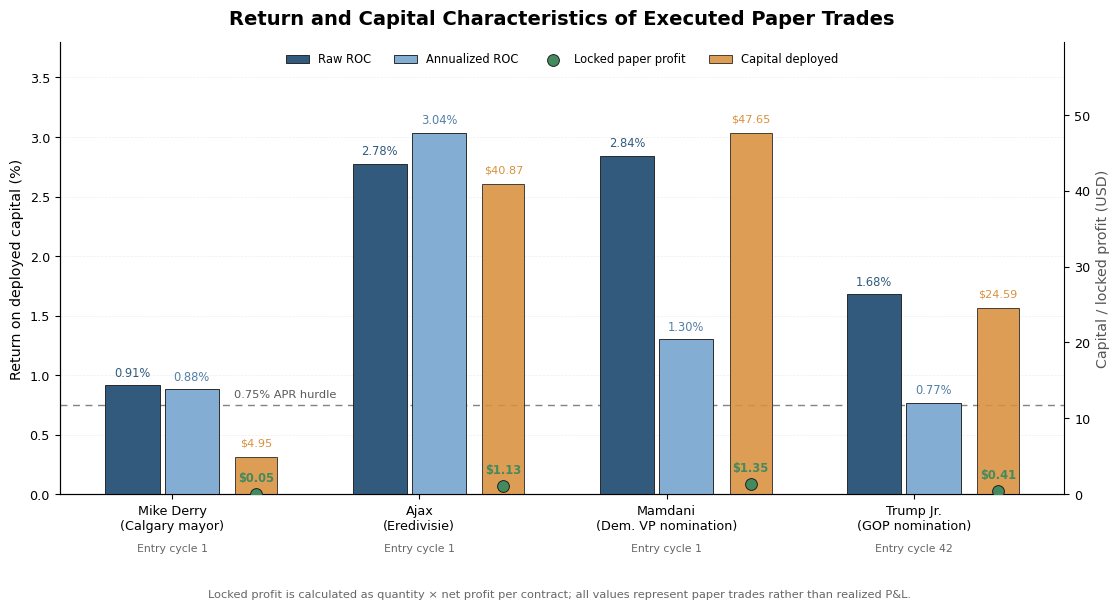

Saved:
/content/drive/MyDrive/kalshi-arbitrage-matcher-results/final_runs/20260901T102353Z/figures/figure_D_trade_level_summary_fixed.png


In [30]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RUN_DIR = Path(
    "/content/drive/MyDrive/"
    "kalshi-arbitrage-matcher-results/"
    "final_runs/"
    "20260901T102353Z"
)

PAPER_DIR = RUN_DIR / "paper_apr075_20260901T114935Z"

FIG_DIR = RUN_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

trades = pd.read_csv(PAPER_DIR / "paper_trades.csv").copy()

numeric_cols = [
    "cycle",
    "quantity",
    "capital",
    "net_per_contract",
    "raw_roc",
    "annualized_roc",
    "days_to_unlock",
]

for col in numeric_cols:
    if col in trades.columns:
        trades[col] = pd.to_numeric(
            trades[col],
            errors="coerce"
        )

trades["raw_roc_pct"] = trades["raw_roc"] * 100
trades["apr_pct"] = trades["annualized_roc"] * 100

trades["locked_profit"] = (
    trades["quantity"]
    * trades["net_per_contract"]
)

label_map = {
    "KXEREDIVISIE-27-AJA":
        "Ajax\n(Eredivisie)",

    "KXVPRESNOMD-28-ZMAM":
        "Mamdani\n(Dem. VP nomination)",

    "KXCALGARYSHAWBY-26SEP14-MDER":
        "Mike Derry\n(Calgary mayor)",

    "KXPRESNOMR-28-DJTJR":
        "Trump Jr.\n(GOP nomination)",
}

trades["display_label"] = (
    trades["ticker"]
    .map(label_map)
    .fillna(trades["ticker"])
)

trades = (
    trades
    .sort_values(["cycle", "ticker"])
    .reset_index(drop=True)
)

fig, ax1 = plt.subplots(figsize=(11.3, 6.1))
ax2 = ax1.twinx()

x = np.arange(len(trades))

roc_color = "#315A7D"
apr_color = "#83ADD3"
capital_color = "#D9903D"
profit_color = "#438A5E"

width = 0.22

raw_bars = ax1.bar(
    x - 0.16,
    trades["raw_roc_pct"],
    width=width,
    color=roc_color,
    edgecolor="#1F1F1F",
    linewidth=0.65,
    label="Raw ROC",
    zorder=3,
)

apr_bars = ax1.bar(
    x + 0.08,
    trades["apr_pct"],
    width=width,
    color=apr_color,
    edgecolor="#1F1F1F",
    linewidth=0.65,
    label="Annualized ROC",
    zorder=3,
)

capital_x = x + 0.34

capital_bars = ax2.bar(
    capital_x,
    trades["capital"],
    width=0.17,
    color=capital_color,
    edgecolor="#1F1F1F",
    linewidth=0.65,
    alpha=0.88,
    label="Capital deployed",
    zorder=2,
)

profit_points = ax2.scatter(
    capital_x,
    trades["locked_profit"],
    s=72,
    color=profit_color,
    edgecolor="#1F1F1F",
    linewidth=0.7,
    zorder=6,
    label="Locked paper profit",
)

for bar, value in zip(
    raw_bars,
    trades["raw_roc_pct"]
):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=8.3,
        color=roc_color,
    )

for bar, value in zip(
    apr_bars,
    trades["apr_pct"]
):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=8.3,
        color="#527FA7",
    )

capital_max = trades["capital"].max()

for bar, value in zip(
    capital_bars,
    trades["capital"]
):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + capital_max * 0.025,
        f"${value:.2f}",
        ha="center",
        va="bottom",
        fontsize=8.1,
        color=capital_color,
    )

for xi, value in zip(
    capital_x,
    trades["locked_profit"]
):
    ax2.annotate(
        f"${value:.2f}",
        xy=(xi, value),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=8.3,
        color=profit_color,
        fontweight="semibold",
    )

ax1.axhline(
    0.75,
    linestyle=(0, (5, 4)),
    color="0.35",
    linewidth=1.0,
    alpha=0.75,
)

ax1.text(
    1.5,
    0.80,
    "0.75% APR hurdle",
    fontsize=8.2,
    color="0.35",
    ha="center",
    va="bottom",
)

ax1.set_xticks(x)

ax1.set_xticklabels(
    trades["display_label"],
    fontsize=9.2,
)

ax1.set_ylabel(
    "Return on deployed capital (%)",
    fontsize=10.3,
)

ax2.set_ylabel(
    "Capital / locked profit (USD)",
    fontsize=10.3,
    color="#555555",
)

ax1.set_title(
    "Return and Capital Characteristics of Executed Paper Trades",
    fontsize=14,
    fontweight="semibold",
    pad=13,
)

for xi, cycle in zip(
    x,
    trades["cycle"]
):
    ax1.text(
        xi,
        -0.11,
        f"Entry cycle {int(cycle)}",
        transform=ax1.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=7.8,
        color="0.40",
    )

ax1.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.20,
)

ax1.set_axisbelow(True)

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

ax1.spines["right"].set_visible(False)

ax1.spines["left"].set_linewidth(0.8)
ax1.spines["bottom"].set_linewidth(0.8)
ax2.spines["right"].set_linewidth(0.8)

ax1.tick_params(
    axis="both",
    labelsize=9.2,
)

ax2.tick_params(
    axis="y",
    labelsize=9.2,
)

ax1.set_ylim(
    0,
    max(
        trades["raw_roc_pct"].max(),
        trades["apr_pct"].max()
    ) * 1.25
)

ax2.set_ylim(
    0,
    capital_max * 1.25
)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.00),
    fontsize=8.3,
)

fig.text(
    0.5,
    0.012,
    "Locked profit is calculated as quantity × net profit per contract; "
    "all values represent paper trades rather than realized P&L.",
    ha="center",
    fontsize=8.2,
    color="0.40",
)

plt.tight_layout(
    rect=[0, 0.055, 1, 1]
)

OUT = FIG_DIR / "figure_D_trade_level_summary_fixed.png"

plt.savefig(
    OUT,
    dpi=400,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:")
print(OUT)


Approved markets: 26
Markets found in opportunity history: 25
Markets traded during run: 4


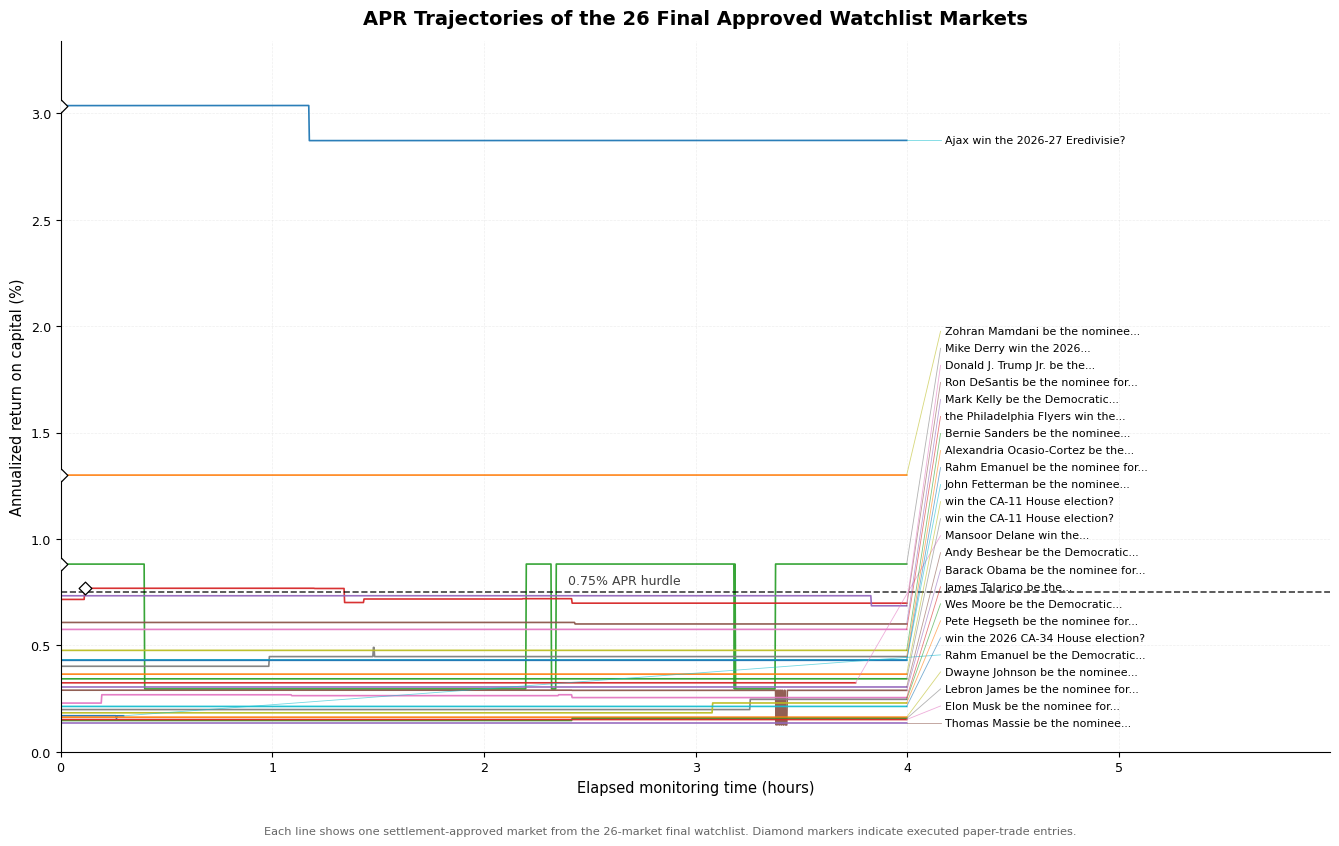

Saved:
/content/drive/MyDrive/kalshi-arbitrage-matcher-results/final_runs/20260901T102353Z/figures/13_all_26_watchlist_apr_over_time.png


,label,ticker,max_apr_pct,mean_apr_pct,observations,traded
4,Ajax win the 2026-27 Eredivisie?,KXEREDIVISIE-27-AJA,3.036412,2.920264,1440,True
24,Zohran Mamdani be the nominee...,KXVPRESNOMD-28-ZMAM,1.300609,1.300473,1440,True
3,Mike Derry win the 2026...,KXCALGARYSHAWBY-26SEP14-MDER,0.882647,0.586776,1440,True
14,Donald J. Trump Jr. be the...,KXPRESNOMR-28-DJTJR,0.768753,0.725669,1440,True
17,Ron DeSantis be the nominee for...,KXPRESNOMR-28-RDS,0.733684,0.731616,1440,False
11,Mark Kelly be the Democratic...,KXPRESNOMD-28-MK,0.608218,0.605369,1440,False
6,the Philadelphia Flyers win the...,KXNHLEAST-27-PHI,0.575733,0.575581,1440,False
8,Alexandria Ocasio-Cortez be the...,KXPRESNOMD-28-AOC,0.490969,0.436705,1440,False
20,Bernie Sanders be the nominee...,KXVPRESNOMD-28-BSAN,0.477128,0.477078,1440,False
23,Rahm Emanuel be the nominee for...,KXVPRESNOMD-28-REMA,0.432255,0.432210,1440,False


In [33]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

RUN_DIR = Path(
    "/content/drive/MyDrive/"
    "kalshi-arbitrage-matcher-results/"
    "final_runs/"
    "20260901T102353Z"
)

PAPER_DIR = RUN_DIR / "paper_apr075_20260901T114935Z"
FIG_DIR = RUN_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

WATCHLIST_PATH = RUN_DIR / "trade_approved_watchlist.csv"
OPPS_PATH = PAPER_DIR / "opportunity_history.csv"
TRADES_PATH = PAPER_DIR / "paper_trades.csv"

assert WATCHLIST_PATH.exists(), f"Missing: {WATCHLIST_PATH}"
assert OPPS_PATH.exists(), f"Missing: {OPPS_PATH}"
assert TRADES_PATH.exists(), f"Missing: {TRADES_PATH}"

watch = pd.read_csv(WATCHLIST_PATH).copy()
opps = pd.read_csv(OPPS_PATH).copy()
trades = pd.read_csv(TRADES_PATH).copy()

for col in ["cycle", "annualized_roc"]:
    if col in opps.columns:
        opps[col] = pd.to_numeric(opps[col], errors="coerce")
    if col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors="coerce")

opps = opps.dropna(subset=["ticker", "cycle", "annualized_roc"]).copy()
trades = trades.dropna(subset=["ticker", "cycle", "annualized_roc"]).copy()

opps["apr_pct"] = opps["annualized_roc"] * 100
trades["apr_pct"] = trades["annualized_roc"] * 100

opps["elapsed_hours"] = (opps["cycle"] - 1) * 10 / 3600
trades["elapsed_hours"] = (trades["cycle"] - 1) * 10 / 3600

approved_tickers = watch["ticker"].dropna().astype(str).unique().tolist()

plot_df = opps[opps["ticker"].astype(str).isin(approved_tickers)].copy()
trade_df = trades[trades["ticker"].astype(str).isin(approved_tickers)].copy()

print("Approved markets:", len(approved_tickers))
print("Markets found in opportunity history:", plot_df['ticker'].nunique())
print("Markets traded during run:", trade_df['ticker'].nunique())

watch["ticker"] = watch["ticker"].astype(str)

label_df = watch[["ticker", "kalshi_title"]].drop_duplicates().copy()

def shorten_title(title, width=34):
    if pd.isna(title):
        return ""
    title = str(title).strip()
    if title.lower().startswith("will "):
        title = title[5:]
    if title.lower().startswith("who will "):
        title = title[9:]
    if len(title) > width:
        title = textwrap.shorten(title, width=width, placeholder="...")
    return title

label_df["short_label"] = label_df["kalshi_title"].apply(shorten_title)

label_map = dict(zip(label_df["ticker"], label_df["short_label"]))

for t in approved_tickers:
    if not label_map.get(t):
        label_map[t] = t

max_apr = (
    plot_df.groupby("ticker", as_index=True)["apr_pct"]
    .max()
    .sort_values(ascending=False)
)

ordered_tickers = max_apr.index.tolist()

fig, ax = plt.subplots(figsize=(13.5, 8.5))

for ticker in ordered_tickers:
    d = (
        plot_df[plot_df["ticker"] == ticker]
        .sort_values("elapsed_hours")
        .copy()
    )

    if d.empty:
        continue

    ax.plot(
        d["elapsed_hours"],
        d["apr_pct"],
        linewidth=1.2,
        alpha=0.95,
    )

APR_THRESHOLD = 0.75

ax.axhline(
    APR_THRESHOLD,
    linestyle="--",
    linewidth=1.2,
    color="black",
    alpha=0.75,
)

ax.text(
    plot_df["elapsed_hours"].max() * 0.60,
    APR_THRESHOLD + 0.025,
    "0.75% APR hurdle",
    ha="left",
    va="bottom",
    fontsize=9,
    color="0.25",
)

for _, row in trade_df.iterrows():
    ax.scatter(
        row["elapsed_hours"],
        row["apr_pct"],
        marker="D",
        s=42,
        facecolor="white",
        edgecolor="black",
        linewidth=0.9,
        zorder=10,
    )

end_points = []

for ticker in ordered_tickers:
    d = (
        plot_df[plot_df["ticker"] == ticker]
        .sort_values("elapsed_hours")
        .copy()
    )
    if d.empty:
        continue

    last = d.iloc[-1]
    end_points.append(
        {
            "ticker": ticker,
            "label": label_map[ticker],
            "x": last["elapsed_hours"],
            "y": last["apr_pct"],
            "max_apr": d["apr_pct"].max(),
        }
    )

end_df = pd.DataFrame(end_points).sort_values("y").reset_index(drop=True)

min_gap = 0.08
adjusted_y = []

for i, row in end_df.iterrows():
    y = row["y"]
    if i == 0:
        adjusted_y.append(y)
    else:
        adjusted_y.append(max(y, adjusted_y[-1] + min_gap))

end_df["y_adj"] = adjusted_y

if len(end_df) > 0:
    ymax_needed = end_df["y_adj"].max()
    current_ylim_top = max(plot_df["apr_pct"].max() * 1.08, APR_THRESHOLD + 0.25)
    if ymax_needed > current_ylim_top:
        shift = ymax_needed - current_ylim_top
        end_df["y_adj"] = end_df["y_adj"] - shift

label_x = plot_df["elapsed_hours"].max() + 0.18

for _, row in end_df.iterrows():
    ax.plot(
        [row["x"], label_x - 0.02],
        [row["y"], row["y_adj"]],
        linewidth=0.6,
        alpha=0.6,
    )
    ax.text(
        label_x,
        row["y_adj"],
        row["label"],
        ha="left",
        va="center",
        fontsize=7.9,
    )

ax.set_title(
    "APR Trajectories of the 26 Final Approved Watchlist Markets",
    fontsize=14,
    fontweight="semibold",
    pad=12,
)

ax.set_xlabel(
    "Elapsed monitoring time (hours)",
    fontsize=10.5,
)

ax.set_ylabel(
    "Annualized return on capital (%)",
    fontsize=10.5,
)

xmax = plot_df["elapsed_hours"].max()
ax.set_xlim(0, xmax + 2.0)

ymax = max(plot_df["apr_pct"].max() * 1.10, APR_THRESHOLD + 0.20)
ax.set_ylim(bottom=0, top=ymax)

ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.5,
    alpha=0.20,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(axis="both", labelsize=9.2)

fig.text(
    0.5,
    0.012,
    "Each line shows one settlement-approved market from the 26-market final watchlist. "
    "Diamond markers indicate executed paper-trade entries.",
    ha="center",
    fontsize=8.2,
    color="0.40",
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

OUT = FIG_DIR / "13_all_26_watchlist_apr_over_time.png"
plt.savefig(
    OUT,
    dpi=400,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:")
print(OUT)

summary = (
    plot_df.groupby("ticker", as_index=False)
    .agg(
        max_apr_pct=("apr_pct", "max"),
        mean_apr_pct=("apr_pct", "mean"),
        observations=("apr_pct", "size"),
    )
    .sort_values("max_apr_pct", ascending=False)
)

summary["label"] = summary["ticker"].map(label_map)
summary["traded"] = summary["ticker"].isin(trade_df["ticker"].unique())

display(
    summary[
        ["label", "ticker", "max_apr_pct", "mean_apr_pct", "observations", "traded"]
    ].head(26)
)


Markets represented: 25
Traded: 4
Not traded: 21


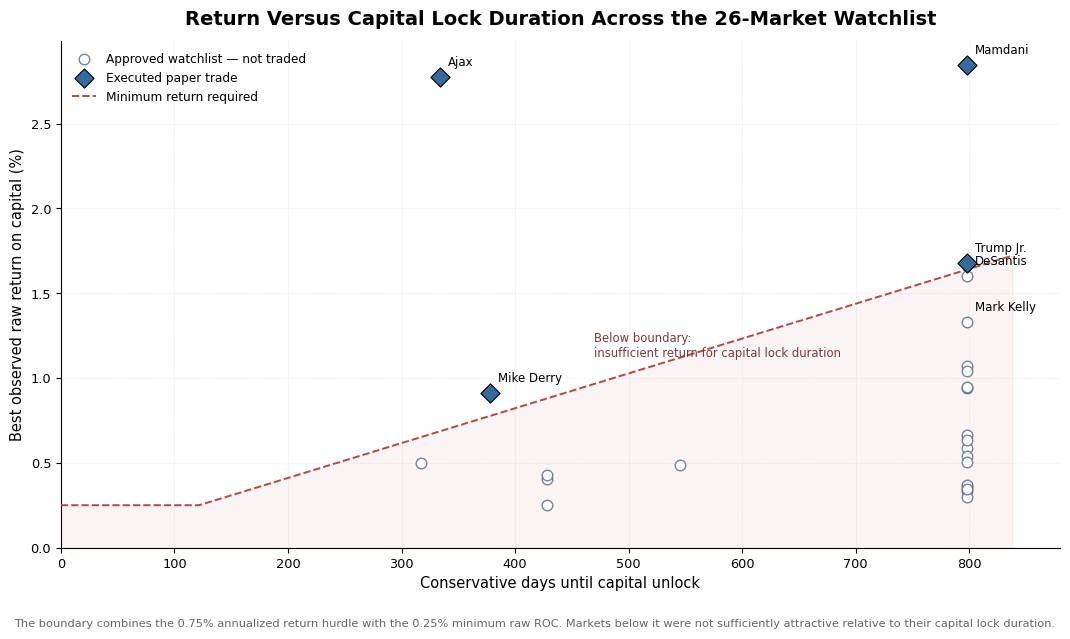

Saved:
/content/drive/MyDrive/kalshi-arbitrage-matcher-results/final_runs/20260901T102353Z/figures/15_watchlist_return_vs_lock_duration.png


,ticker,days_to_unlock,raw_roc_pct,apr_pct,traded
0,KXEREDIVISIE-27-AJA,333.624333,2.7754,3.036412,True
1,KXVPRESNOMD-28-ZMAM,797.965650,2.8434,1.300609,True
2,KXCALGARYSHAWBY-26SEP14-MDER,377.923983,0.9139,0.882647,True
3,KXPRESNOMR-28-DJTJR,798.082319,1.6809,0.768753,True
4,KXPRESNOMR-28-RDS,797.972710,1.6040,0.733684,False
5,KXPRESNOMD-28-MK,798.031045,1.3298,0.608218,False
6,KXNHLEAST-27-PHI,316.923983,0.4999,0.575733,False
7,KXPRESNOMD-28-AOC,798.070513,1.0735,0.490969,False
8,KXVPRESNOMD-28-BSAN,797.965650,1.0431,0.477128,False
9,KXVPRESNOMD-28-REMA,797.965650,0.9450,0.432255,False


In [34]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RUN_DIR = Path(
    "/content/drive/MyDrive/"
    "kalshi-arbitrage-matcher-results/"
    "final_runs/"
    "20260901T102353Z"
)

PAPER_DIR = RUN_DIR / "paper_apr075_20260901T114935Z"
FIG_DIR = RUN_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

WATCHLIST_PATH = RUN_DIR / "trade_approved_watchlist.csv"
OPPS_PATH = PAPER_DIR / "opportunity_history.csv"
TRADES_PATH = PAPER_DIR / "paper_trades.csv"

watch = pd.read_csv(WATCHLIST_PATH).copy()
opps = pd.read_csv(OPPS_PATH).copy()
trades = pd.read_csv(TRADES_PATH).copy()

numeric_cols = [
    "raw_roc",
    "annualized_roc",
    "days_to_unlock",
]

for col in numeric_cols:
    if col in opps.columns:
        opps[col] = pd.to_numeric(opps[col], errors="coerce")

for col in ["raw_roc", "annualized_roc", "days_to_unlock"]:
    if col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors="coerce")

opps = opps.dropna(
    subset=["ticker", "raw_roc", "days_to_unlock"]
).copy()

approved_tickers = (
    watch["ticker"]
    .dropna()
    .astype(str)
    .unique()
)

opps = opps[
    opps["ticker"].astype(str).isin(approved_tickers)
].copy()

best_idx = (
    opps.groupby("ticker")["annualized_roc"]
    .idxmax()
)

best = (
    opps.loc[best_idx]
    .copy()
    .reset_index(drop=True)
)

best["raw_roc_pct"] = best["raw_roc"] * 100
best["apr_pct"] = best["annualized_roc"] * 100

traded_tickers = set(
    trades["ticker"].dropna().astype(str)
)

best["traded"] = best["ticker"].astype(str).isin(traded_tickers)

print("Markets represented:", len(best))
print("Traded:", best["traded"].sum())
print("Not traded:", (~best["traded"]).sum())

name_map = {
    "KXEREDIVISIE-27-AJA": "Ajax",
    "KXVPRESNOMD-28-ZMAM": "Mamdani",
    "KXCALGARYSHAWBY-26SEP14-MDER": "Mike Derry",
    "KXPRESNOMR-28-DJTJR": "Trump Jr.",
    "KXPRESNOMR-28-RDS": "DeSantis",
    "KXPRESNOMD-28-MK": "Mark Kelly",
}

APR_HURDLE = 0.0075
MIN_RAW_ROC = 0.0025

x_curve = np.linspace(
    0,
    best["days_to_unlock"].max() * 1.05,
    500
)

required_raw = np.maximum(
    MIN_RAW_ROC,
    APR_HURDLE * x_curve / 365
)

required_raw_pct = required_raw * 100

fig, ax = plt.subplots(figsize=(10.8, 6.4))

not_traded = best[~best["traded"]]
traded = best[best["traded"]]

ax.scatter(
    not_traded["days_to_unlock"],
    not_traded["raw_roc_pct"],
    s=58,
    facecolor="white",
    edgecolor="#5F7182",
    linewidth=1.0,
    alpha=0.85,
    label="Approved watchlist — not traded",
    zorder=4,
)

ax.scatter(
    traded["days_to_unlock"],
    traded["raw_roc_pct"],
    s=95,
    marker="D",
    color="#356A9A",
    edgecolor="black",
    linewidth=0.8,
    label="Executed paper trade",
    zorder=7,
)

ax.plot(
    x_curve,
    required_raw_pct,
    linestyle="--",
    linewidth=1.4,
    color="#B04A4A",
    label="Minimum return required",
    zorder=3,
)

ax.fill_between(
    x_curve,
    0,
    required_raw_pct,
    color="#B04A4A",
    alpha=0.06,
    zorder=1,
)

for _, row in best.iterrows():

    ticker = str(row["ticker"])

    if ticker not in name_map:
        continue

    label = name_map[ticker]

    ax.annotate(
        label,
        xy=(
            row["days_to_unlock"],
            row["raw_roc_pct"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8.5,
        ha="left",
        va="bottom",
    )

ax.text(
    x_curve.max() * 0.56,
    required_raw_pct[int(len(required_raw_pct) * 0.56)] + 0.16,
    "Below boundary:\ninsufficient return for capital lock duration",
    fontsize=8.4,
    color="#7A3B3B",
    ha="left",
)

ax.set_title(
    "Return Versus Capital Lock Duration Across the 26-Market Watchlist",
    fontsize=14,
    fontweight="semibold",
    pad=12,
)

ax.set_xlabel(
    "Conservative days until capital unlock",
    fontsize=10.5,
)

ax.set_ylabel(
    "Best observed raw return on capital (%)",
    fontsize=10.5,
)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.5,
    alpha=0.20,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(
    axis="both",
    labelsize=9.3,
)

ax.legend(
    frameon=False,
    fontsize=8.7,
    loc="upper left",
)

fig.text(
    0.5,
    0.012,
    "The boundary combines the 0.75% annualized return hurdle with the 0.25% minimum raw ROC. "
    "Markets below it were not sufficiently attractive relative to their capital lock duration.",
    ha="center",
    fontsize=8.2,
    color="0.40",
)

plt.tight_layout(rect=[0, 0.045, 1, 1])

OUT = FIG_DIR / "15_watchlist_return_vs_lock_duration.png"

plt.savefig(
    OUT,
    dpi=400,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:")
print(OUT)

display(
    best[
        [
            "ticker",
            "days_to_unlock",
            "raw_roc_pct",
            "apr_pct",
            "traded",
        ]
    ]
    .sort_values("apr_pct", ascending=False)
    .reset_index(drop=True)
)


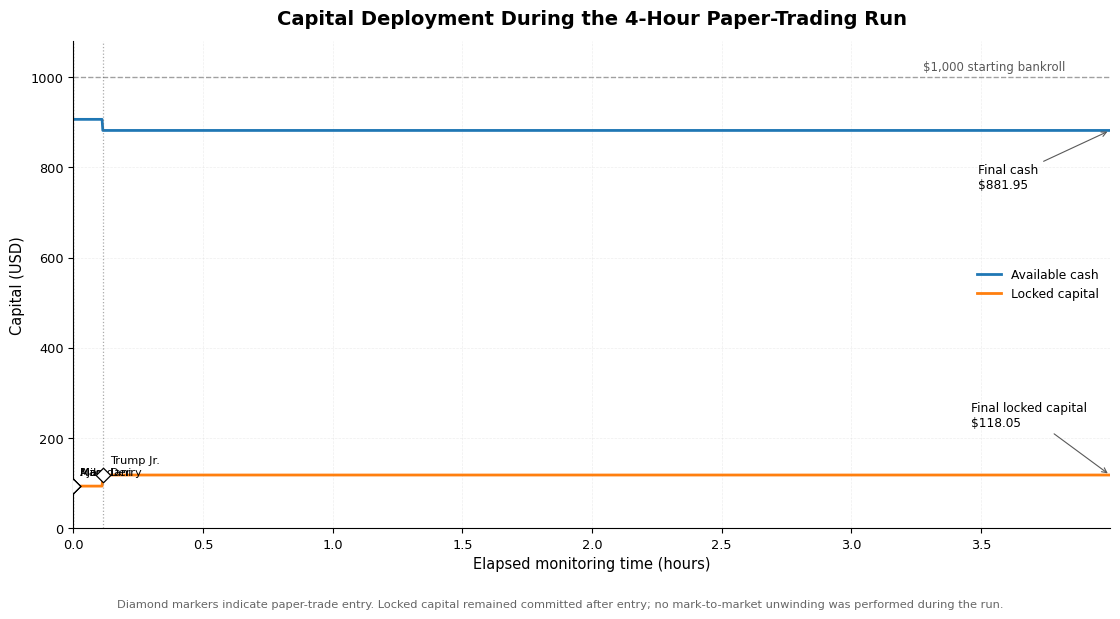

Saved:
/content/drive/MyDrive/kalshi-arbitrage-matcher-results/final_runs/20260901T102353Z/figures/16_capital_deployment_over_time.png


In [35]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RUN_DIR = Path(
    "/content/drive/MyDrive/"
    "kalshi-arbitrage-matcher-results/"
    "final_runs/"
    "20260901T102353Z"
)

PAPER_DIR = RUN_DIR / "paper_apr075_20260901T114935Z"

FIG_DIR = RUN_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

EQUITY_PATH = PAPER_DIR / "equity_history.csv"
TRADES_PATH = PAPER_DIR / "paper_trades.csv"

equity = pd.read_csv(EQUITY_PATH).copy()
trades = pd.read_csv(TRADES_PATH).copy()

for col in [
    "cycle",
    "cash",
    "locked_capital",
    "deployed_fraction",
    "locked_profit",
    "paper_equity_if_all_settle",
]:
    if col in equity.columns:
        equity[col] = pd.to_numeric(
            equity[col],
            errors="coerce"
        )

for col in [
    "cycle",
    "capital",
    "annualized_roc",
]:
    if col in trades.columns:
        trades[col] = pd.to_numeric(
            trades[col],
            errors="coerce"
        )

equity = equity.dropna(
    subset=["cycle", "cash", "locked_capital"]
).copy()

trades = trades.dropna(
    subset=["cycle", "capital"]
).copy()

equity["elapsed_hours"] = (
    (equity["cycle"] - 1) * 10 / 3600
)

trades["elapsed_hours"] = (
    (trades["cycle"] - 1) * 10 / 3600
)

name_map = {
    "KXEREDIVISIE-27-AJA": "Ajax",
    "KXVPRESNOMD-28-ZMAM": "Mamdani",
    "KXCALGARYSHAWBY-26SEP14-MDER": "Mike Derry",
    "KXPRESNOMR-28-DJTJR": "Trump Jr.",
}

trades["display_name"] = (
    trades["ticker"]
    .map(name_map)
    .fillna(trades["ticker"])
)

fig, ax = plt.subplots(figsize=(11.3, 6.2))

ax.plot(
    equity["elapsed_hours"],
    equity["cash"],
    linewidth=2.0,
    label="Available cash",
)

ax.plot(
    equity["elapsed_hours"],
    equity["locked_capital"],
    linewidth=2.0,
    label="Locked capital",
)

ax.axhline(
    1000,
    linestyle="--",
    linewidth=1.0,
    color="0.35",
    alpha=0.55,
)

ax.text(
    equity["elapsed_hours"].max() * 0.82,
    1015,
    "$1,000 starting bankroll",
    fontsize=8.5,
    color="0.35",
)

for _, row in trades.iterrows():

    ax.axvline(
        row["elapsed_hours"],
        linestyle=":",
        linewidth=0.9,
        color="0.40",
        alpha=0.55,
    )

    # find locked capital close to entry time
    idx = (
        equity["elapsed_hours"] - row["elapsed_hours"]
    ).abs().idxmin()

    y = equity.loc[idx, "locked_capital"]

    ax.scatter(
        row["elapsed_hours"],
        y,
        marker="D",
        s=55,
        facecolor="white",
        edgecolor="black",
        linewidth=0.9,
        zorder=10,
    )

    ax.annotate(
        row["display_name"],
        xy=(row["elapsed_hours"], y),
        xytext=(5, 8),
        textcoords="offset points",
        fontsize=8.2,
        ha="left",
    )

final = equity.iloc[-1]

ax.annotate(
    f"Final locked capital\n${final['locked_capital']:.2f}",
    xy=(
        final["elapsed_hours"],
        final["locked_capital"]
    ),
    xytext=(-100, 35),
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=0.8,
        color="0.35",
    ),
    fontsize=8.7,
    ha="left",
)

ax.annotate(
    f"Final cash\n${final['cash']:.2f}",
    xy=(
        final["elapsed_hours"],
        final["cash"]
    ),
    xytext=(-95, -42),
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=0.8,
        color="0.35",
    ),
    fontsize=8.7,
    ha="left",
)

ax.set_title(
    "Capital Deployment During the 4-Hour Paper-Trading Run",
    fontsize=14,
    fontweight="semibold",
    pad=12,
)

ax.set_xlabel(
    "Elapsed monitoring time (hours)",
    fontsize=10.5,
)

ax.set_ylabel(
    "Capital (USD)",
    fontsize=10.5,
)

ax.set_xlim(
    0,
    equity["elapsed_hours"].max()
)

ax.set_ylim(
    0,
    1080
)

ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.5,
    alpha=0.20,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(
    axis="both",
    labelsize=9.3,
)

ax.legend(
    frameon=False,
    fontsize=8.8,
    loc="center right",
)

fig.text(
    0.5,
    0.012,
    "Diamond markers indicate paper-trade entry. Locked capital remained committed after entry; "
    "no mark-to-market unwinding was performed during the run.",
    ha="center",
    fontsize=8.2,
    color="0.40",
)

plt.tight_layout(
    rect=[0, 0.045, 1, 1]
)

OUT = FIG_DIR / "16_capital_deployment_over_time.png"

plt.savefig(
    OUT,
    dpi=400,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:")
print(OUT)


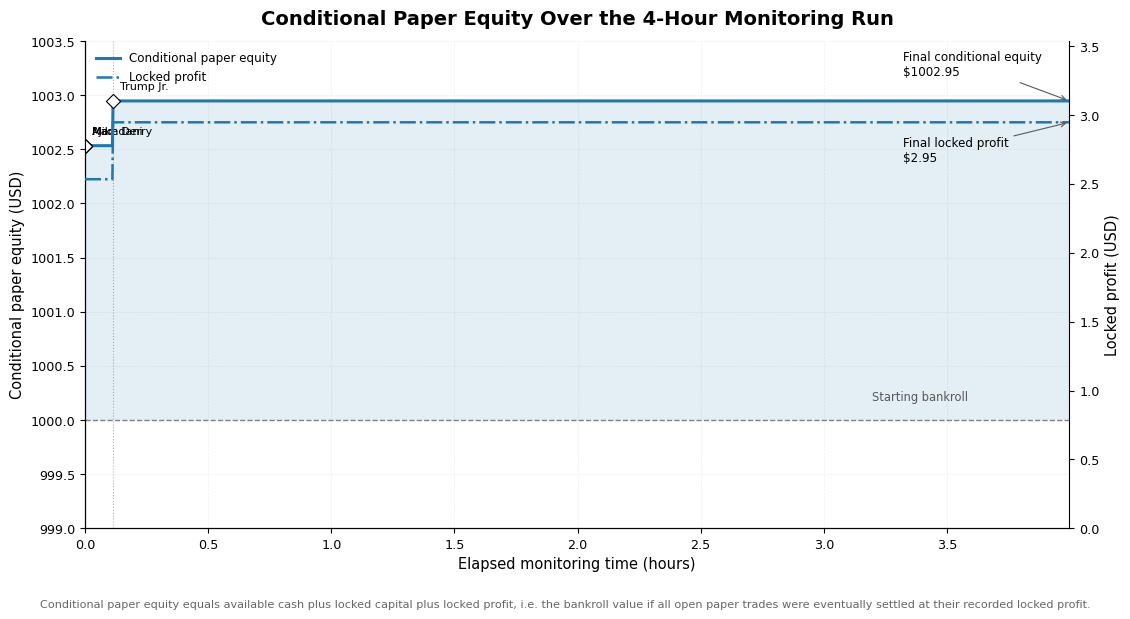

Saved:
/content/drive/MyDrive/kalshi-arbitrage-matcher-results/final_runs/20260901T102353Z/figures/17_conditional_equity_over_time.png


In [36]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RUN_DIR = Path(
    "/content/drive/MyDrive/"
    "kalshi-arbitrage-matcher-results/"
    "final_runs/"
    "20260901T102353Z"
)

PAPER_DIR = RUN_DIR / "paper_apr075_20260901T114935Z"
FIG_DIR = RUN_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

EQUITY_PATH = PAPER_DIR / "equity_history.csv"
TRADES_PATH = PAPER_DIR / "paper_trades.csv"

assert EQUITY_PATH.exists(), f"Missing: {EQUITY_PATH}"
assert TRADES_PATH.exists(), f"Missing: {TRADES_PATH}"

equity = pd.read_csv(EQUITY_PATH).copy()
trades = pd.read_csv(TRADES_PATH).copy()

equity_numeric = [
    "cycle",
    "cash",
    "locked_capital",
    "locked_profit",
    "paper_equity_if_all_settle",
]

for col in equity_numeric:
    if col in equity.columns:
        equity[col] = pd.to_numeric(equity[col], errors="coerce")

trade_numeric = [
    "cycle",
    "capital",
    "annualized_roc",
]

for col in trade_numeric:
    if col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors="coerce")

equity = equity.dropna(subset=["cycle"]).copy()
trades = trades.dropna(subset=["cycle"]).copy()

if "paper_equity_if_all_settle" not in equity.columns or equity["paper_equity_if_all_settle"].isna().all():
    required = {"cash", "locked_capital", "locked_profit"}
    missing = required - set(equity.columns)
    assert not missing, f"Need columns to reconstruct conditional equity: {missing}"

    equity["paper_equity_if_all_settle"] = (
        equity["cash"]
        + equity["locked_capital"]
        + equity["locked_profit"]
    )

assert "locked_profit" in equity.columns, "locked_profit column missing"

equity["elapsed_hours"] = (equity["cycle"] - 1) * 10 / 3600
trades["elapsed_hours"] = (trades["cycle"] - 1) * 10 / 3600

name_map = {
    "KXEREDIVISIE-27-AJA": "Ajax",
    "KXVPRESNOMD-28-ZMAM": "Mamdani",
    "KXCALGARYSHAWBY-26SEP14-MDER": "Mike Derry",
    "KXPRESNOMR-28-DJTJR": "Trump Jr.",
}

if "ticker" in trades.columns:
    trades["display_name"] = trades["ticker"].map(name_map).fillna(trades["ticker"])
else:
    trades["display_name"] = "Trade"

fig, ax1 = plt.subplots(figsize=(11.4, 6.2))
ax2 = ax1.twinx()

ax1.plot(
    equity["elapsed_hours"],
    equity["paper_equity_if_all_settle"],
    linewidth=2.2,
    label="Conditional paper equity",
    zorder=4,
)

STARTING_BANKROLL = 1000.0

ax1.axhline(
    STARTING_BANKROLL,
    linestyle="--",
    linewidth=1.0,
    color="0.35",
    alpha=0.75,
)

ax1.fill_between(
    equity["elapsed_hours"],
    STARTING_BANKROLL,
    equity["paper_equity_if_all_settle"],
    where=(equity["paper_equity_if_all_settle"] >= STARTING_BANKROLL),
    alpha=0.12,
    zorder=1,
)

ax2.plot(
    equity["elapsed_hours"],
    equity["locked_profit"],
    linewidth=1.8,
    linestyle="-.",
    label="Locked profit",
    zorder=3,
)

for _, row in trades.iterrows():

    x = row["elapsed_hours"]

    idx = (equity["elapsed_hours"] - x).abs().idxmin()
    y = equity.loc[idx, "paper_equity_if_all_settle"]

    ax1.axvline(
        x,
        linestyle=":",
        linewidth=0.8,
        color="0.45",
        alpha=0.55,
        zorder=2,
    )

    ax1.scatter(
        x,
        y,
        marker="D",
        s=52,
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        zorder=8,
    )

    ax1.annotate(
        row["display_name"],
        xy=(x, y),
        xytext=(5, 8),
        textcoords="offset points",
        fontsize=8.0,
        ha="left",
    )

final = equity.iloc[-1]

ax1.annotate(
    f"Final conditional equity\n${final['paper_equity_if_all_settle']:.2f}",
    xy=(final["elapsed_hours"], final["paper_equity_if_all_settle"]),
    xytext=(-120, 18),
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=0.8,
        color="0.35",
    ),
    fontsize=8.6,
    ha="left",
)

ax2.annotate(
    f"Final locked profit\n${final['locked_profit']:.2f}",
    xy=(final["elapsed_hours"], final["locked_profit"]),
    xytext=(-120, -28),
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=0.8,
        color="0.35",
    ),
    fontsize=8.6,
    ha="left",
)

ax1.text(
    equity["elapsed_hours"].max() * 0.80,
    STARTING_BANKROLL + 0.15,
    "Starting bankroll",
    fontsize=8.3,
    color="0.35",
    ha="left",
    va="bottom",
)

ax1.set_title(
    "Conditional Paper Equity Over the 4-Hour Monitoring Run",
    fontsize=14,
    fontweight="semibold",
    pad=12,
)

ax1.set_xlabel(
    "Elapsed monitoring time (hours)",
    fontsize=10.5,
)

ax1.set_ylabel(
    "Conditional paper equity (USD)",
    fontsize=10.5,
)

ax2.set_ylabel(
    "Locked profit (USD)",
    fontsize=10.5,
)

ax1.set_xlim(0, equity["elapsed_hours"].max())

ymin = min(STARTING_BANKROLL - 1, equity["paper_equity_if_all_settle"].min() - 0.2)
ymax = max(equity["paper_equity_if_all_settle"].max() + 0.5, STARTING_BANKROLL + 3.5)
ax1.set_ylim(ymin, ymax)

ax2.set_ylim(0, max(equity["locked_profit"].max() * 1.20, 0.5))

ax1.grid(
    axis="both",
    linestyle="--",
    linewidth=0.5,
    alpha=0.20,
)

ax1.set_axisbelow(True)

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax1.spines["left"].set_linewidth(0.8)
ax1.spines["bottom"].set_linewidth(0.8)
ax2.spines["right"].set_linewidth(0.8)

ax1.tick_params(axis="both", labelsize=9.2)
ax2.tick_params(axis="y", labelsize=9.2)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    frameon=False,
    fontsize=8.6,
    loc="upper left",
)

fig.text(
    0.5,
    0.012,
    "Conditional paper equity equals available cash plus locked capital plus locked profit, "
    "i.e. the bankroll value if all open paper trades were eventually settled at their recorded locked profit.",
    ha="center",
    fontsize=8.1,
    color="0.40",
)

plt.tight_layout(rect=[0, 0.045, 1, 1])

OUT = FIG_DIR / "17_conditional_equity_over_time.png"

plt.savefig(
    OUT,
    dpi=400,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:")
print(OUT)
